<a href="https://colab.research.google.com/github/chatwipa-sur/SRCC_detection/blob/main/%5BStrong_Augmented%5D_baseline_student_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Strong Augmented] Baseline of student model
- Train model with strong augmentation

In [ ]:
# Standard library for file and directory operations
import os
from datetime import datetime
import sys

# Library for parsing XML files (used for annotations)
import xml.etree.ElementTree as ET

# Core PyTorch library for tensor operations
import torch
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
import torchvision.transforms.functional as F
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import random_split
import torch.nn as nn
import torchvision
from torchvision.ops import nms, box_iou
from torchvision.models import ResNet50_Weights, ResNet34_Weights, ResNet18_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedKFold

# Library for numerical computations
import numpy as np
from scipy.ndimage import maximum_filter
import pandas as pd
import time

# Library for data visualization
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Mount the drive with google colab notebook
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Create Dataset

In [ ]:
# Make heatmaps using the utility functions from the centernet repo
# Draw a Gaussian centered at a point on a heatmap
def draw_msra_gaussian(heatmap, center, sigma=7):
  # Total size (radius) of the Gaussian region
  tmp_size = sigma * 6

  # Round the x and y center to nearest int
  mu_x = int(center[0] + 0.5)
  mu_y = int(center[1] + 0.5)

  # Get heatmap dimensions
  w, h = heatmap.shape[0], heatmap.shape[1]

  # Upper-left and bottom-right corners of the Gaussian patch
  ul = [int(mu_x - tmp_size), int(mu_y - tmp_size)]
  br = [int(mu_x + tmp_size + 1), int(mu_y + tmp_size + 1)]

  # If Gaussian patch is completely outside the heatmap, return
  if ul[0] >= h or ul[1] >= w or br[0] < 0 or br[1] < 0:
    return heatmap

  # Create a 2D Gaussian
  size = 2 * tmp_size + 1 # Size of the Gaussian patch
  x = np.arange(0, size, 1, np.float32) # x coordinates
  y = x[:, np.newaxis] # y coordinates
  x0 = y0 = size // 2 # Center of the Gaussian
  g = np.exp(- ((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2)) # 2D Gaussian formula

  # Compute valid bounds for placing the Gaussian patch on the heatmap
  g_x = max(0, -ul[0]), min(br[0], h) - ul[0]
  g_y = max(0, -ul[1]), min(br[1], w) - ul[1]
  img_x = max(0, ul[0]), min(br[0], h)
  img_y = max(0, ul[1]), min(br[1], w)

  # Place the Gaussian on the heatmap using max to retain highest intensity
  heatmap[img_y[0]:img_y[1], img_x[0]:img_x[1]] = np.maximum(
    heatmap[img_y[0]:img_y[1], img_x[0]:img_x[1]],
    g[g_y[0]:g_y[1], g_x[0]:g_x[1]])

  return heatmap

# Draw a dense regression value map around a center point
def draw_dense_reg(regmap, heatmap, center, value, radius, is_offset=False):
  # Size of the square region
  diameter = 2 * radius + 1
  # Create Gaussian mask
  gaussian = gaussian2D((diameter, diameter), sigma=diameter / 6)

  # Convert value to float32 and reshape to [dim, 1, 1]
  value = np.array(value, dtype=np.float32).reshape(-1, 1, 1)
  dim = value.shape[0]

  # Create a repeated value map of shape [dim, H, W]
  reg = np.ones((dim, diameter*2+1, diameter*2+1), dtype=np.float32) * value

  # If it's an offset, adjust the values using distance from center
  if is_offset and dim == 2:
    delta = np.arange(diameter*2+1) - radius
    reg[0] = reg[0] - delta.reshape(1, -1)
    reg[1] = reg[1] - delta.reshape(-1, 1)

  # Center coordinates
  x, y = int(center[0]), int(center[1])

  # Heatmap dimensions
  height, width = heatmap.shape[0:2]

  # Compute boundaries (clipping at image edges)
  left, right = min(x, radius), min(width - x, radius + 1)
  top, bottom = min(y, radius), min(height - y, radius + 1)

  # Crop regions from heatmap, regmap, Gaussian, and value maps
  masked_heatmap = heatmap[y - top:y + bottom, x - left:x + right]
  masked_regmap = regmap[:, y - top:y + bottom, x - left:x + right]
  masked_gaussian = gaussian[radius - top:radius + bottom,
                             radius - left:radius + right]
  masked_reg = reg[:, radius - top:radius + bottom,
                      radius - left:radius + right]

  # Only update if region is valid (non-zero size)
  if min(masked_gaussian.shape) > 0 and min(masked_heatmap.shape) > 0: # TODO debug

    # Create a mask where Gaussian is stronger than existing heatmap
    idx = (masked_gaussian >= masked_heatmap).reshape(1, masked_gaussian.shape[0],
                                                      masked_gaussian.shape[1])

    # Update regmap only where mask is True (using Gaussian gate)
    masked_regmap = (1-idx) * masked_regmap + idx * masked_reg

  # Write updated region back to original regmap
  regmap[:, y - top:y + bottom, x - left:x + right] = masked_regmap

  return regmap

def gaussian2D(shape, sigma=1):
    # Get center and coordinate grid
    m, n = [(ss - 1.) / 2. for ss in shape]
    y, x = np.ogrid[-m:m+1,-n:n+1]

    # Apply 2D Gaussian function
    h = np.exp(-(x * x + y * y) / (2 * sigma * sigma))

    # Remove near-zero values for stability
    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    return h

def make_hm_regr(target, input_size=512, MODEL_SCALE=4):

    IN_SCALE = 1
    # make output heatmap for single class
    hm = np.zeros([input_size//MODEL_SCALE, input_size//MODEL_SCALE], dtype=np.float32)
    # make regr heatmap
    regr = np.zeros([2, input_size//MODEL_SCALE, input_size//MODEL_SCALE], dtype=np.float32)

    if target.empty:
        return hm, regr

    center = np.array([target["x"] + target["w"]//2, target["y"] + target["h"]//2,
                       target["w"], target["h"]]).T

    # make a center point
    for c in center:
        hm = draw_msra_gaussian(hm, [int(c[0])//MODEL_SCALE//IN_SCALE,
                                     int(c[1])//MODEL_SCALE//IN_SCALE],
                                sigma=np.clip(c[2]*c[3]//2000, 5, 10))

    # convert targets to its center
    regrs = center[:, 2:]/input_size/IN_SCALE

    # plot regr values to mask
    for r, c in zip(regrs, center):
        for i in range(-2, 3):
            for j in range(-2, 3):
                try:
                    regr[:, int(c[0])//MODEL_SCALE//IN_SCALE+i,
                         int(c[1])//MODEL_SCALE//IN_SCALE+j] = r
                except:
                    pass
    regr[0] = regr[0].T; regr[1] = regr[1].T;

    return hm, regr

def pred2box(hm, regr, thresh=0.99, MODEL_SCALE=4, input_size=512):
    pred = hm > thresh
    pred_center = np.where(pred)
    pred_r = regr[:, pred].T  # Shape: [N, 2] for w, h
    boxes = []
    scores = hm[pred]

    for i, b in enumerate(pred_r):
        cx = pred_center[1][i] * MODEL_SCALE
        cy = pred_center[0][i] * MODEL_SCALE

        w = b[0] * input_size
        h = b[1] * input_size

        x1 = cx - w /2
        y1 = cy - h /2

        arr = np.clip([x1, y1, w, h], 0, input_size)
        boxes.append(arr)

    return np.asarray(boxes), scores


# Assuming `image` is a torch.Tensor of shape (3, H, W)
def unnormalize_tensor(image):
  mean = [0.485, 0.456, 0.406]
  std  = [0.229, 0.224, 0.225]
  for t, m, s in zip(image, mean, std):
    t.mul_(s).add_(m)
  return image

In [ ]:
class SignetRingCellPatchCenterNetDataset(Dataset):
  def __init__(self, image_dir, annotation_dir, patch_size=512, transform=None):
    # Initialize parameters
    self.patch_size = patch_size
    self.stride = patch_size//2
    self.transform = transform
    self.image_information = []

    # Loop over positive and negative folders
    for class_type in ['positive', 'negative']:
      full_image_dir = os.path.join(image_dir, class_type)
      full_anno_dir = os.path.join(annotation_dir, class_type)

      # Iterate over image files in the folder
      for fname in os.listdir(full_image_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
          # Collect image path
          image_path = os.path.join(full_image_dir, fname)

          # Collect annotation path
          if class_type == "positive":
            anno_filename = fname.replace('.png', '.xml').replace('.jpg', '.xml').replace('.jpeg', '.xml')
            anno_path = os.path.join(full_anno_dir, anno_filename)
          else:
            anno_path = None  # no annotation for negatives

          # Get the size of image
          image = cv2.imread(image_path)
          height, width = image.shape[:2]
          self.stride = self.stride if class_type == 'positive' else 512
          window_size = self.patch_size

          # Calculate padding size
          pad_h = (self.stride - (height - window_size) % self.stride) % self.stride
          pad_w = (self.stride - (width - window_size) % self.stride) % self.stride
          padded_height = height + pad_h
          padded_width = width + pad_w

          # Generate sliding window patches
          for top in range(0, height - self.patch_size + 1, self.stride):
            for left in range(0, width - self.patch_size + 1, self.stride):
              self.image_information.append({
                  'image_path': image_path,
                  'annotation_path': anno_path,
                  'crop_box': (left, top, left + self.patch_size, top + self.patch_size),
                  'original_size': (width, height),
                  'flag': 1 if class_type == 'positive' else 0
              })

  def __len__(self):
    return len(self.image_information) # Total number of patches

  def __getitem__(self, idx):
    # Get image for this index
    image_info = self.image_information[idx]
    image = cv2.imread(image_info['image_path'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Crop patch
    width, height = image_info['original_size']
    pad_h = (self.stride - (height - self.patch_size) % self.stride) % self.stride
    pad_w = (self.stride - (width - self.patch_size) % self.stride) % self.stride
    image = np.pad(image, ((0, pad_h), (0, pad_w), (0,0)), mode='constant', constant_values=0)
    left, top, right, bottom = image_info['crop_box']
    image_patch = image[top:bottom, left:right]

    # Get type of image
    flag = image_info['flag']

    # Load and process annotations
    boxes_list = []
    category_ids = []
    if image_info['annotation_path'] is not None:
        tree = ET.parse(image_info['annotation_path'])
        root = tree.getroot()

        crop_xmin, crop_ymin, crop_xmax, crop_ymax = image_info['crop_box']
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name == 'ring_cell_cancer':
                bbox = obj.find('bndbox')
                xmin = int(bbox.find('xmin').text)
                ymin = int(bbox.find('ymin').text)
                xmax = int(bbox.find('xmax').text)
                ymax = int(bbox.find('ymax').text)

                if (xmin >= crop_xmin and xmax <= crop_xmax) and (ymin >= crop_ymin and ymax <= crop_ymax):
                    new_xmin = xmin - crop_xmin
                    new_ymin = ymin - crop_ymin
                    new_xmax = xmax - crop_xmin
                    new_ymax = ymax - crop_ymin
                    boxes_list.append((new_xmin, new_ymin,
                                       new_xmax - new_xmin,
                                       new_ymax - new_ymin))
                    category_ids.append(1)  # ring_cell_cancer

    # Apply transform
    if self.transform and len(boxes_list) > 0:
        transformed = self.transform(
            image=image_patch,
            bboxes=boxes_list,
            category_ids=category_ids
        )
        image_patch = transformed['image']
        boxes_list = transformed['bboxes']
    elif self.transform:
        transformed = self.transform(image=image_patch, bboxes=[], category_ids=[])
        image_patch = transformed['image']

    # Generate heatmap + regression map
    if len(boxes_list) == 0:
        hm = np.zeros([self.patch_size // 4, self.patch_size // 4], dtype=np.float32)
        regr = np.zeros([2, self.patch_size // 4, self.patch_size // 4], dtype=np.float32)
    else:
        target = pd.DataFrame(boxes_list, columns=['x', 'y', 'w', 'h'])
        hm, regr = make_hm_regr(target)

    return image_patch, hm, regr, boxes_list, flag

### 1.1 Transform function

#### Training transform

In [ ]:
# Transform function - Training set
train_transform = A.Compose([
    # Spatial augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=(-0.05, 0.05), scale=(0.9, 1.1), rotate=(-15, 15), p=0.5),

    # Normalization & Tensor conversion
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),  # converts image and bounding boxes to torch.Tensor
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

#### Validation and Test transform

In [ ]:
# Transform function - Validation and Test set
val_test_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

/usr/local/lib/python3.11/dist-packages/albumentations/core/composition.py:331: UserWarning: Got processor for bboxes, but no transform to process it.
  self._set_keys()


### 1.2 DataLoader

#### Main functions

In [ ]:
def custom_collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    hms = torch.stack([torch.from_numpy(item[1]).float() for item in batch])
    regrs = torch.stack([torch.from_numpy(item[2]).float() for item in batch])
    gt_boxes = [item[3] for item in batch]
    flags = [item[4] for item in batch]
    return images, hms, regrs, gt_boxes, flags

def get_dataloaders(fold_root_dir, train_fold, val_fold, test_fold,
                    transform_train, transform_val_test, batch_size=16):

    # Load training dataset (concat multiple folds)
    train_datasets = []
    for idx in train_fold_idxs:
        fold_name = folds[idx]
        dataset = SignetRingCellPatchCenterNetDataset(
            image_dir=os.path.join(fold_root_dir, fold_name, 'images'),
            annotation_dir=os.path.join(fold_root_dir, fold_name, 'annotations'),
            transform=transform_train
        )
        train_datasets.append(dataset)
    train_dataset = ConcatDataset(train_datasets)

    # Load val dataset
    val_fold = folds[val_fold_idx]
    val_dataset = SignetRingCellPatchCenterNetDataset(
        image_dir=os.path.join(fold_root_dir, val_fold, 'images'),
        annotation_dir=os.path.join(fold_root_dir, val_fold, 'annotations'),
        transform=transform_val_test
    )

    # Load test dataset
    test_fold = folds[test_fold_idx]
    test_dataset = SignetRingCellPatchCenterNetDataset(
        image_dir=os.path.join(fold_root_dir, test_fold, 'images'),
        annotation_dir=os.path.join(fold_root_dir, test_fold, 'annotations'),
        transform=transform_val_test
    )

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

    return train_loader, val_loader, test_loader

#### Check `get_dataloaders`

In [ ]:
folds = ['fold1', 'fold2', 'fold3', 'fold4']

for test_fold_idx, test_fold_name in enumerate(folds):
    val_fold_idx = (test_fold_idx + 1) % 4
    train_fold_idxs = [i for i in range(4) if i != test_fold_idx and i != val_fold_idx]

    print(f"==== Test Fold: {folds[test_fold_idx]}, Val Fold: {folds[val_fold_idx]}, Train Folds: {[folds[i] for i in train_fold_idxs]} ====")

    train_loader, val_loader, test_loader = get_dataloaders(
        fold_root_dir = "/content/drive/MyDrive/Dissertation_Chatwipa/dataset",
        train_fold = [folds[i] for i in train_fold_idxs],
        val_fold = folds[val_fold_idx],
        test_fold = folds[test_fold_idx],
        transform_train = train_transform,
        transform_val_test = val_test_transform,
        batch_size = 32
    )

    # Total number of images
    num_train = len(train_loader.dataset)
    num_val = len(val_loader.dataset)
    num_test = len(test_loader.dataset)

    print(f"Train: {num_train} images")
    print(f"Validation: {num_val} images")
    print(f"Test: {num_test} images")

==== Test Fold: fold1, Val Fold: fold2, Train Folds: ['fold3', 'fold4'] ====
Train: 3128 images
Validation: 1672 images
Test: 1666 images
==== Test Fold: fold2, Val Fold: fold3, Train Folds: ['fold1', 'fold4'] ====
Train: 3241 images
Validation: 1553 images
Test: 1672 images
==== Test Fold: fold3, Val Fold: fold4, Train Folds: ['fold1', 'fold2'] ====
Train: 3338 images
Validation: 1575 images
Test: 1553 images
==== Test Fold: fold4, Val Fold: fold1, Train Folds: ['fold2', 'fold3'] ====
Train: 3225 images
Validation: 1666 images
Test: 1575 images


## 2. Model Training

### 2.1 CenterNet Model

- The model is based on [CenterNet Baseline](https://www.kaggle.com/hocop1/centernet-baseline) and [CenterNet Starterkit](https://www.kaggle.com/code/kyoshioka47/centernet-starterkit-pytorch)

#### CenterNet class

In [ ]:
class double_conv(nn.Module):
    '''(conv => BN => ReLU) * 2'''
    def __init__(self, in_ch, out_ch):
        super(double_conv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ELU(inplace=True), # Change from ReLU to ELU
            nn.Dropout2d(p=0.3),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ELU(inplace=True), # Change from ReLU to ELU
            nn.Dropout2d(p=0.3),
        )

    def forward(self, x):
        x = self.conv(x)
        return x

class up(nn.Module):
    def __init__(self, in_ch, out_ch, bilinear=True):
        super(up, self).__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_ch//2, in_ch//2, 2, stride=2)
        self.conv = double_conv(in_ch, out_ch)

    def forward(self, x1, x2=None):
        x1 = self.up(x1)
        if x2 is not None:
            x = torch.cat([x2, x1], dim=1)
            # input is CHW
            diffY = x2.size()[2] - x1.size()[2]
            diffX = x2.size()[3] - x1.size()[3]

            x1 = F.pad(x1, (diffX // 2, diffX - diffX//2,
                            diffY // 2, diffY - diffY//2))
        else:
            x = x1
        x = self.conv(x)
        return x

class centernet(nn.Module):
    def __init__(self, n_classes=1, model_name="resnet34"):
        super(centernet, self).__init__()

        # Create model backbone
        if model_name == "resnet34":
            basemodel = torchvision.models.resnet34(weights=ResNet34_Weights.DEFAULT)
            self.num_ch = 512
        elif model_name == "resnet18":
            basemodel = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
            self.num_ch = 512

        # Remove the last two layers (average pooling and linear layer)
        self.base_model = nn.Sequential(*list(basemodel.children())[:-2])

        # Freeze earlier layers except layer3 and layer4
        for name, param in basemodel.named_parameters():
            if "layer3" in name or "layer4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.up1 = up(self.num_ch, 512)
        self.up2 = up(512, 256)
        self.up3 = up(256, 256)

        # Output classification
        self.outc = nn.Conv2d(256, n_classes, 1)

        # Output residue
        self.outr = nn.Conv2d(256, 2, 1)

    def forward(self, x):
        x = self.base_model(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        outc = self.outc(x)
        outr = self.outr(x)
        return outc, outr

#### Loss function

In [ ]:
# From centernet repo
# Modified focal loss to detect object centers via heatmap
def neg_loss(pred, gt, pos_gamma=3, neg_gamma=4):
  ''' Modified focal loss. Exactly the same as CornerNet.
      Runs faster and costs a little bit more memory
      Args:
      pred: (B, 1, H, W)
      gt: (B, 1, H, W)
      pos_gamma: focusing parameter for positive examples
      neg_gamma: focusing parameter for negative examples
    '''

  pred = pred.unsqueeze(1).float()
  pred = torch.clamp(pred, min=1e-4, max=1 - 1e-4)
  gt = gt.unsqueeze(1).float()

  pos_inds = gt.eq(1).float() # Locations where there is a true object center
  neg_inds = gt.lt(1).float()  # All other pixels
  neg_weights = torch.pow(1 - gt, 4) # Higher weight for pixels farther from center

  loss = 0

  pos_loss = torch.log(pred + 1e-12) * torch.pow(1 - pred, pos_gamma) * pos_inds
  neg_loss = torch.log(1 - pred + 1e-12) * torch.pow(pred, neg_gamma) * neg_weights * neg_inds

  num_pos  = pos_inds.float().sum()
  pos_loss = pos_loss.sum()
  neg_loss = neg_loss.sum()

  if num_pos == 0:
    loss = (loss - neg_loss)
  else:
    loss = loss - (pos_loss + neg_loss) / (num_pos + 1e-4)

  return loss

# Smooth L1 regression loss for offsets, widths, etc.
def _reg_loss(regr, gt_regr, mask):
  ''' L1 regression loss
      regr: (B, N, 2)
      gt_regr: (B, N, 2)
      mask: (B, N)
  '''
  num = mask.float().sum()
  mask = mask.unsqueeze(2).expand_as(gt_regr)  # (B, N, 2)

  regr = regr * mask
  gt_regr = gt_regr * mask

  regr_loss = nn.functional.smooth_l1_loss(regr, gt_regr, reduction='sum')
  regr_loss = regr_loss / (num + 1e-4)

  return regr_loss


def centerloss(prediction, mask, regr, weight=100, size_average=True):
    """
    Combines heatmap focal loss and regression L1 loss into a total loss.

    Args:
        prediction: (B, 3, H, W) where [:, 0] = heatmap, [:, 1:] = regr
        mask: (B, H, W) – binary mask for object centers
        regr: (B, 2, H, W) – regression ground truth
        weight: float – weight of regression loss
        size_average: bool – average the final loss across batch

    Returns:
        total_loss, mask_loss, regr_loss
    """

    # Mask loss
    pred_mask = prediction[:, 0]
    mask_loss = neg_loss(pred_mask, mask)

    # Regression loss
    pred_regr = prediction[:, 1:]
    # Flatten tensors for _reg_loss: (B, 2, H, W) -> (B, H*W, 2)
    pred_regr_flat = pred_regr.permute(0, 2, 3, 1).reshape(pred_regr.size(0), -1, 2)
    regr_gt_flat = regr.permute(0, 2, 3, 1).reshape(regr.size(0), -1, 2)
    mask_flat = mask.view(mask.size(0), -1)  # (B, H*W)

    # Regression loss using helper
    regr_loss = _reg_loss(pred_regr_flat, regr_gt_flat, mask_flat) * weight

    # Total loss (with weighting)
    total_loss = mask_loss + regr_loss

    if not size_average:
        total_loss *= prediction.shape[0]

    return total_loss, mask_loss, regr_loss

#### Evaluation function

In [ ]:
# Convert bounding boxes from (x, y, w, h) format to (x1, y1, x2, y2) format.
def boxes_conversion_xy(boxes_x1y1wh):
    """
    Args:
        boxes: A set of bounding boxes in (x, y, width, height) format

    Returns:
        torch.Tensor: Bounding boxes in (x1, y1, x2, y2) format as a float32 tensor.
                      (x1, y1) is the top-left corner, (x2, y2) is the bottom-right.
    """

    if isinstance(boxes_x1y1wh, torch.Tensor):
        boxes_x1y1x2y2 = boxes_x1y1wh.clone()
        boxes_x1y1x2y2[:, 2] = boxes_x1y1x2y2[:, 0] + boxes_x1y1x2y2[:, 2]  # x2 = x + w
        boxes_x1y1x2y2[:, 3] = boxes_x1y1x2y2[:, 1] + boxes_x1y1x2y2[:, 3]  # y2 = y + h
    else:
        boxes_x1y1wh = np.array(boxes_x1y1wh)
        boxes_x1y1x2y2 = boxes_x1y1wh.copy()
        boxes_x1y1x2y2[:, 2] = boxes_x1y1x2y2[:, 0] + boxes_x1y1x2y2[:, 2]
        boxes_x1y1x2y2[:, 3] = boxes_x1y1x2y2[:, 1] + boxes_x1y1x2y2[:, 3]
        boxes_x1y1x2y2 = torch.tensor(boxes_x1y1x2y2, dtype=torch.float32)

    return boxes_x1y1x2y2

def match_predictions(pred_boxes, gt_boxes, positive_flag):
    """
    Args:
        pred_boxes: List of predicted boxes in xywh
        gt_boxes: List of ground truth boxes in xywh
        positive_flag: True if image has GT boxes (positive sample), else False
    Returns:
        tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg
    """
    tp_pos = fp_pos = tn_pos = fn_pos = fp_neg = tn_neg = 0

    # ---- Positive Images: Precision and Recall ---- #
    if positive_flag:
        # No label from both gound-truth and prediction -> TN
        if len(gt_boxes) == 0 and len(pred_boxes) == 0:
            tp_pos, fp_pos, tn_pos, fn_pos = 0, 0, 1, 0
            return tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg

        # No label from ground-truth -> all preds are FP
        if len(gt_boxes) == 0:
            tp_pos, fp_pos, tn_pos, fn_pos = 0, len(pred_boxes), 0, 0
            return tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg

        # No label from prediction -> all preds are FN
        if len(pred_boxes) == 0:
            tp_pos, fp_pos, tn_pos, fn_pos = 0, 0, 0, len(gt_boxes)
            return tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg

        # Convert bounding boxes from (x, y, w, h) format to (x1, y1, x2, y2) format
        pred_boxes_xyxy = boxes_conversion_xy(pred_boxes)
        gt_boxes_xyxy = boxes_conversion_xy(gt_boxes)

        # Calculate ious from library
        ious = box_iou(gt_boxes_xyxy, pred_boxes_xyxy)  # return [num_gt, num_pred]

        # Initialize tensor
        matched_gt = torch.zeros(len(gt_boxes), dtype=torch.bool)
        matched_pred = torch.zeros(len(pred_boxes), dtype=torch.bool)
        for j in range(ious.size(1)):  # loop all prediction
            for i in range(ious.size(0)):  # loop all ground-truth
                # skips already-matched ground truth boxes
                if not (matched_gt[i]) and (ious[i, j] >= 0.3):
                    matched_gt[i] = True
                    matched_pred[j] = True
                    break

        tp_pos = matched_gt.sum().item()
        fp_pos = (~matched_pred).sum().item()
        fn_pos = (~matched_gt).sum().item()

    # ---- Negative Images: Normal Region False Positive ---- #
    else:  # only TN or FP
        tn_neg = 1 if len(pred_boxes) == 0 else 0
        fp_neg = 0 if tn_neg == 1 else len(pred_boxes)

    return tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg

def pool_numpy(data, size=3):
    max_filtered = maximum_filter(data, size=size, mode='constant')
    return np.where(data == max_filtered, data, 0)

def compute_metrics(tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, total_gt_boxes, flag_list):

    # ---- Positive Images : Precision and Recall ---- #
    precision = tp_pos / (tp_pos + fp_pos + 1e-6)
    recall = tp_pos / (tp_pos + fn_pos + 1e-6)
    instance_recall = tp_pos / total_gt_boxes
    f1 = 2 * precision * instance_recall / (precision + instance_recall + 1e-6)

    # ---- Negative Images: FPs ---- #
    num_normal_images = sum(1 for flag in flag_list if not flag)
    normal_region_fp = fp_neg / num_normal_images
    normal_fp_score = max((100 - normal_region_fp), 0)

    return {
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Instance Recall': instance_recall,
        'Normal Region FP': normal_region_fp,
        'FP Score': normal_fp_score
    }

def compute_froc_valid_recall(predictions_by_thresh, gt_boxes_list, flag_list, thresholds, fp_levels=[1, 2, 4, 8, 16, 32]):

    total_gt_boxes = sum(len(boxes) for boxes in gt_boxes_list)
    fp_per_image_list = []
    recall_list = []

    # For each threshold, compute FP/image and recall
    for threshold in thresholds:
        preds_list = predictions_by_thresh[threshold]

        total_tp_pos = total_fp_pos = total_tn_pos = total_fn_pos = total_fp_neg = total_tn_neg = 0

        for boxes_sorted, gt_boxes, flag in zip(preds_list, gt_boxes_list, flag_list):
            tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg = match_predictions(boxes_sorted, gt_boxes, flag)
            total_tp_pos += tp_pos
            total_fp_pos += fp_pos
            total_tn_pos += tn_pos
            total_fn_pos += fn_pos
            total_fp_neg += fp_neg
            total_tn_neg += tn_neg

        metric = compute_metrics(total_tp_pos, total_fp_pos, total_tn_pos, total_fn_pos, total_fp_neg, total_gt_boxes, flag_list)
        instance_recall = metric['Instance Recall']
        precision = metric['Precision']
        normal_region_fp = metric['Normal Region FP']

        # Save FP per image and recall for interpolation later
        fp_per_image_list.append(normal_region_fp)
        recall_list.append(instance_recall)

    # Ensure FP levels are sorted
    fp_per_image_list = np.array(fp_per_image_list)
    recall_list = np.array(recall_list)

    # Sort by FP per image (ascending)
    sorted_indices = np.argsort(fp_per_image_list)
    fp_per_image_list = fp_per_image_list[sorted_indices]
    recall_list = recall_list[sorted_indices]

    # Interpolate recall at required FP levels
    recalls_at_fp = {}
    for fp_level in fp_levels:
        if fp_level <= fp_per_image_list[-1]:
            interpolated_recall = np.interp(fp_level, fp_per_image_list, recall_list)
            recalls_at_fp[fp_level] = interpolated_recall
        else:
            # If FP level is beyond available range, assign last available recall
            recalls_at_fp[fp_level] = recall_list[-1]

    # Compute FROC as average recall at the specified FP levels
    froc_score = np.mean(list(recalls_at_fp.values()))

    return froc_score, recalls_at_fp

### 2.3 Training Function

#### Define training function

In [ ]:
def train(epoch, save_dir, best_f1, epochs_no_improve, early_stop_patience,
          train_loader,val_loader, model, optimizer):

    # Set model to training mode
    model.train()
    print(f'\nEpoch {epoch + 1}/{epochs}')

    # Initialize loss value
    running_loss, running_mask, running_regr = 0.0, 0.0, 0.0

    # Start epoch timer
    epoch_start = time.time()

    # Iterate over batches
    for idx, (img, hm_gt, regr_gt, _ , _ ) in enumerate(train_loader):

        # Start timer for this batch
        batch_start = time.time()

        # Move batch tensors to the device (GPU or CPU)
        img = img.to(device)
        hm_gt = hm_gt.to(device)
        regr_gt = regr_gt.to(device)

        # Reset gradients for new batch
        optimizer.zero_grad()

        # Forward pass: predict heatmap and regression outputs
        hm_pred, regr_pred = model(img)
        hm_pred = torch.sigmoid(hm_pred)

        # Concatenate heatmap and regression predictions along channel dimension
        preds = torch.cat((hm_pred, regr_pred), dim=1)

        # Compute combined loss (total, mask, and regression)
        loss, mask_loss, regr_loss = centerloss(preds, hm_gt, regr_gt)

        # Visualization: plot the GT and predicted heatmap for only first batch of epoch
        if idx == 0 and (epoch % 5 == 0 or epoch == 0):
            plt.subplot(1, 2, 1)
            plt.imshow(hm_gt[0].squeeze().cpu().detach().numpy(), cmap='hot')
            plt.title('GT Heatmap')

            plt.subplot(1, 2, 2)
            plt.imshow(hm_pred[0].squeeze().cpu().detach().numpy(), cmap='hot')
            plt.title('Pred Heatmap')
            plt.show()

        # Backpropagation: compute gradients
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update model weights
        optimizer.step()

        # Accumulate loss values for reporting
        running_loss += loss.item()
        running_mask += mask_loss.item()
        running_regr += regr_loss.item()

        # Compute running average losses for display
        train_loss = running_loss / (idx + 1)
        avg_mask = running_mask / (idx + 1)
        avg_regr = running_regr / (idx + 1)

    # Average losses over the entire epoch after training completes
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch + 1} completed in {epoch_time:.2f} seconds.")
    print(f"Train loss : {running_loss / len(train_loader):.4f}")
    print(f"Train mask loss : {running_mask / len(train_loader):.4f}")
    print(f"Train regr loss : {running_regr / len(train_loader):.4f}")

    # Run validation after training epoch
    val_loss, avg_mask, avg_regr, metrics = validate()

    # Step learning rate scheduler based on validation loss
    scheduler.step(val_loss)

    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Current Learning Rate: {current_lr}')

    # Check if F1 improved
    f1 = metrics['F1 Score']
    if f1 > best_f1:
        print(f"F1 Score improved from {best_f1:.4f} to {f1:.4f}")
        best_f1 = f1
        epochs_no_improve = 0  # reset counter

        # Save best model
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_loss
        }, f'{save_dir}/best_model.pth')

    else:
        epochs_no_improve += 1
        print(f"No improvement in F1 Score for {epochs_no_improve} epoch(s)")

    # Early stopping condition
    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping triggered after {early_stop_patience} epochs without improvement.")
        early_stop_flag = True
    else:
        early_stop_flag = False

    return early_stop_flag, best_f1, epochs_no_improve, train_loss, val_loss, metrics

#### Define validation function

In [ ]:
def validate():
    # Set model to evaluation mode
    model.eval()

    # Initialize loss trackers
    running_loss = 0.0
    running_mask = 0.0
    running_regr = 0.0

    # Initialize counters for evaluation metrics
    total_tp_pos = total_fp_pos = total_tn_pos = total_fn_pos = total_fp_neg = total_tn_neg = 0
    thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
    predictions_by_thresh = {t: [] for t in thresholds}
    gt_boxes_list = []
    flag_list = []


    # Disable gradient computations during validation
    with torch.no_grad():
        for idx, (img_batch, hm_gt_batch, regr_gt_batch, box_gt_batch, flags_batch) in enumerate(val_loader):

            # Move inputs to the correct device
            img_batch = img_batch.to(device)
            hm_gt_batch = hm_gt_batch.to(device)
            regr_gt_batch = regr_gt_batch.to(device)

            # Forward pass
            hm_pred_batch, regr_pred_batch = model(img_batch)
            hm_pred_batch = torch.sigmoid(hm_pred_batch)  # Apply sigmoid to get probabilities

            # Plot GT and predicted heatmaps for the first batch every 2 epochs
            if idx == 0 and (epoch % 5 == 0 or epoch == 0):
                plt.subplot(1, 2, 1)
                plt.imshow(hm_gt_batch[0].squeeze().cpu().numpy(), cmap='hot')
                plt.title('GT Heatmap')

                plt.subplot(1, 2, 2)
                plt.imshow(hm_pred_batch[0].squeeze().cpu().numpy(), cmap='hot')
                plt.title('Pred Heatmap')
                plt.show()

            # Concatenate predicted heatmaps and regression maps for loss computation
            preds = torch.cat((hm_pred_batch, regr_pred_batch), dim=1)
            loss, mask_loss, regr_loss = centerloss(preds, hm_gt_batch, regr_gt_batch)

            # Update running loss totals
            running_loss += loss.item()
            running_mask += mask_loss.item()
            running_regr += regr_loss.item()

            # Process each image in the batch
            for i, (img, hm, regr, gt_boxes, flag) in enumerate(zip(img_batch, hm_pred_batch, regr_pred_batch, box_gt_batch, flags_batch)):

                # Post-process predicted heatmap and regression outputs
                hm = pool_numpy(hm.cpu().numpy().squeeze(0))  # Apply local max pooling
                regr = regr.cpu().numpy()

                # Convert predictions to bounding boxes and scores
                boxes, scores = pred2box(hm, regr, thresh=0.3)

                # Apply NMS if there are any predicted boxes
                boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
                scores_tensor = torch.tensor(scores, dtype=torch.float32)
                if boxes_tensor.numel() > 0:
                    boxes_xyxy = boxes_conversion_xy(boxes_tensor)  # Convert to (x1, y1, x2, y2) format
                    keep = nms(boxes_xyxy, scores_tensor, iou_threshold=0.3)  # Apply NMS
                    boxes_sorted = boxes_tensor[keep].numpy()
                    scores_sorted = scores_tensor[keep].numpy()
                else:
                    boxes_sorted = np.empty((0, 4))
                    scores_sorted = np.empty((0,))

                # Match predicted boxes with ground truth to compute evaluation metrics
                tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg = match_predictions(boxes_sorted, gt_boxes, flag)
                total_tp_pos += tp_pos
                total_fp_pos += fp_pos
                total_tn_pos += tn_pos
                total_fn_pos += fn_pos
                total_fp_neg += fp_neg
                total_tn_neg += tn_neg

                ## ---- FROC Computation ---- ##
                gt_boxes_list.append(gt_boxes)
                flag_list.append(flag)

                # Group predictions by confidence threshold with NMS per threshold
                for t in thresholds:
                    # Get predicted bounding boxes and scores from heatmap and regression output
                    boxes, scores = pred2box(hm, regr, t)

                    # Convert to tensors for NMS
                    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
                    scores_tensor = torch.tensor(scores, dtype=torch.float32)

                    # Apply Non-Maximum Suppression if any boxes are predicted
                    if boxes_tensor.numel() > 0:
                        boxes_xyxy = boxes_conversion_xy(boxes_tensor)
                        keep = nms(boxes_xyxy, scores_tensor, iou_threshold=0.5)

                        # Filter top boxes and scores
                        boxes_sorted = boxes[keep.numpy()]
                        scores_sorted = scores[keep.numpy()]
                    else:
                        # No predictions, initialize empty arrays
                        boxes_sorted = np.empty((0, 4))
                        scores_sorted = np.empty((0,))

                    # Store for this threshold
                    predictions_by_thresh[t].append(boxes_sorted)

    # Compute average losses
    avg_loss = running_loss / len(val_loader)
    avg_mask = running_mask / len(val_loader)
    avg_regr = running_regr / len(val_loader)

    # Print validation loss results
    print(f"\nValidation loss      : {avg_loss:.4f}")
    print(f"Validation mask loss : {avg_mask:.4f}")
    print(f"Validation regr loss : {avg_regr:.4f}")

    # Compute total number of ground truth boxes across all images
    total_gt_boxes = sum(len(boxes) for boxes in gt_boxes_list)

    # Compute precision, recall, F1, and FP metrics
    metrics = compute_metrics(total_tp_pos, total_fp_pos, total_tn_pos, total_fn_pos, total_fp_neg, total_gt_boxes, flag_list)
    froc_score, recall_at_fps = compute_froc_valid_recall(predictions_by_thresh, gt_boxes_list, flag_list, thresholds)

    # Add FROC Score to the metrics dict
    metrics['FROC Score'] = froc_score

    # Print core evaluation metrics
    print(f"Precision:        {metrics['Precision']:.4f}")
    print(f"Instance Recall:  {metrics['Instance Recall']:.4f}")
    print(f"F1 Score:         {metrics['F1 Score']:.4f}")
    print(f"Normal Region FP: {metrics['Normal Region FP']}")
    print(f"FROC Score:       {froc_score:.4f}")

    return avg_loss, avg_mask, avg_regr, metrics

#### Define test function

In [ ]:
def plot_pred_gt(image, boxes_pred, boxes_gt, hm_pred):
    # ----- Visualization ----- #
    # Unnormalize image
    image = unnormalize_tensor(image.clone())

    # Convert tensor image to numpy
    image = image.permute(1, 2, 0).cpu().numpy()
    image = (image * 255).astype(np.uint8)

    # Copy image for drawing boxes
    image_copy = image.copy()

    # Draw pseudo-label boxes in red
    for box in boxes_pred:
        x, y, w, h = map(int, box)
        cv2.rectangle(image_copy, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Draw ground truth boxes in green
    for box in boxes_gt:
        x1, y1, w, h = map(int, box)
        cv2.rectangle(image_copy, (x1, y1), (x1 + w, y1 + h), (0, 255, 0), 2)

    # Create subplot for visualization
    fig, axs = plt.subplots(1, 2, figsize=(5, 3.5))

    # Display image with pseudo and GT boxes
    axs[0].imshow(image_copy)
    axs[0].set_title("Red: Pred Boxes | Green: GT Boxes", fontsize = 10)
    axs[0].axis('off')

    # Display heatmap
    axs[1].imshow(hm_pred, cmap='hot', interpolation='nearest', vmin=0, vmax=1)
    axs[1].set_title("Pred Heatmap", fontsize = 10)
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def test(model, test_loader, device, save_dir, plot=False):
    # Save path
    save_path = os.path.join(save_dir, 'test_results.csv')

    # Set model to evaluation mode
    model.eval()

    # Initialize counters for overall performance metrics
    total_tp_pos = total_fp_pos = total_tn_pos = total_fn_pos = total_fp_neg = total_tn_neg = 0

    # Structures for FROC evaluation
    thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
    predictions_by_thresh = {t: [] for t in thresholds}
    gt_boxes_list = []
    flag_list = []

    # Store per-image results for CSV logging
    result_rows = []

    with torch.no_grad():
        for batch_idx, (img_batch, hm_batch, regr_batch, box_gt_batch, flags_batch) in enumerate(test_loader):

            # Get images in batch
            img_batch = img_batch.to(device)

            # Forward pass through the model
            hms_pred, regrs_pred = model(img_batch)
            hms_pred = torch.sigmoid(hms_pred)

            # Iterate through each image in the batch
            for i, (img, hm, regr, gt_boxes, flag) in enumerate(zip(img_batch, hms_pred, regrs_pred, box_gt_batch, flags_batch)):
                index = batch_idx * test_loader.batch_size + i  # Global image index

                # Preprocess predictions
                hm = pool_numpy(hm.cpu().numpy().squeeze(0))
                regr = regr.cpu().numpy()

                # Get predicted bounding boxes and scores from heatmap and regression output
                boxes, scores = pred2box(hm, regr, 0.3)

                # Convert to tensors for NMS
                boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
                scores_tensor = torch.tensor(scores, dtype=torch.float32)

                # Apply Non-Maximum Suppression if any boxes are predicted
                if boxes_tensor.numel() > 0:
                    boxes_xyxy = boxes_conversion_xy(boxes_tensor)
                    keep = nms(boxes_xyxy, scores_tensor, iou_threshold=0.3)

                    # # Filter top boxes and scores
                    boxes_sorted = boxes[keep.numpy()]
                    scores_sorted = scores[keep.numpy()]
                else:
                    # No predictions, initialize empty arrays
                    boxes_sorted = np.empty((0, 4))
                    scores_sorted = np.empty((0,))

                # Compute TP, FP, TN, FN for this image
                tp_pos, fp_pos, tn_pos, fn_pos, fp_neg, tn_neg = match_predictions(boxes_sorted, gt_boxes, flag)
                total_tp_pos += tp_pos
                total_fp_pos += fp_pos
                total_tn_pos += tn_pos
                total_fn_pos += fn_pos
                total_fp_neg += fp_neg
                total_tn_neg += tn_neg

                # Append per-image results for CSV
                result_rows.append({
                    'Image_Index': index,
                    'TP_positive': tp_pos,
                    'FP_positive': fp_pos,
                    'TN_positive': tn_pos,
                    'FN_positive': fn_pos,
                    'FP_negative': fp_neg,
                    'TN_negative': tn_neg,
                    'Num_Pred_Boxes': len(boxes_sorted),
                    'Num_GT_Boxes': len(gt_boxes),
                    'Positive_Flag': flag
                })

                # Plot images
                if plot and i == 0:
                    plot_pred_gt(img, boxes_sorted, gt_boxes, hm)

                ## ---- FROC Computation ---- ##
                gt_boxes_list.append(gt_boxes)
                flag_list.append(flag)

                # Group predictions by confidence threshold with NMS per threshold
                for t in thresholds:
                    # Get predicted bounding boxes and scores from heatmap and regression output
                    boxes, scores = pred2box(hm, regr, t)

                    # Convert to tensors for NMS
                    boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
                    scores_tensor = torch.tensor(scores, dtype=torch.float32)

                    # Apply Non-Maximum Suppression if any boxes are predicted
                    if boxes_tensor.numel() > 0:
                        boxes_xyxy = boxes_conversion_xy(boxes_tensor)
                        keep = nms(boxes_xyxy, scores_tensor, iou_threshold=0.5)

                        # Filter top boxes and scores
                        boxes_sorted = boxes[keep.numpy()]
                        scores_sorted = scores[keep.numpy()]
                    else:
                        # No predictions, initialize empty arrays
                        boxes_sorted = np.empty((0, 4))
                        scores_sorted = np.empty((0,))

                    # Store for this threshold
                    predictions_by_thresh[t].append(boxes_sorted)

        total_gt_boxes = sum(len(boxes) for boxes in gt_boxes_list)
        metrics = compute_metrics(total_tp_pos, total_fp_pos, total_tn_pos, total_fn_pos, total_fp_neg, total_gt_boxes, flag_list)
        froc_score, recall_at_fps = compute_froc_valid_recall(predictions_by_thresh, gt_boxes_list, flag_list, thresholds)

        # Append summary row to CSV data
        result_rows.append({
            'Image_Index': 'Total',
            'TP': total_tp_pos,
            'FP': total_fp_pos,
            'TN': total_tn_pos,
            'FN': total_fn_pos,
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall'],
            'F1_Score': metrics['F1 Score'],
            'FPs': metrics['FP Score'],
            'FROC_Score': froc_score
        })

        # # Save results to CSV file
        df = pd.DataFrame(result_rows)

        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_csv(save_path, index=False)

        # Print final performance summary
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Instance Recall: {metrics['Instance Recall']:.4f}")
        print(f"F1 Score:  {metrics['F1 Score']:.4f}")
        print(f"FPs:       {metrics['FP Score']:.4f}")
        print(f"FROC Score: {froc_score:.4f}")

    return metrics, froc_score, recall_at_fps, save_path

### 2.2 Train model

#### Check model's output size and parameters

In [ ]:
# Check if it runs correctly
model = centernet(model_name='resnet18')
model(torch.rand(1,3,512,512))[0].size()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


torch.Size([1, 1, 128, 128])

In [ ]:
# Total parameters
total_params = sum(p.numel() for p in model.parameters())

# Trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 18,851,139
Trainable parameters: 18,168,067


#### Training loop

==== Test Fold: fold1, Val Fold: fold2, Train Folds: ['fold3', 'fold4'] ====

Epoch 1/100


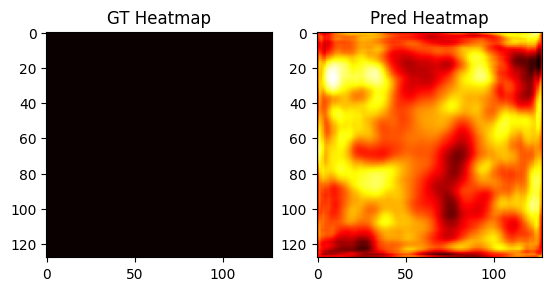


Epoch 1 completed in 200.61 seconds.
Train loss : 220.1737
Train mask loss : 212.7610
Train regr loss : 7.4127


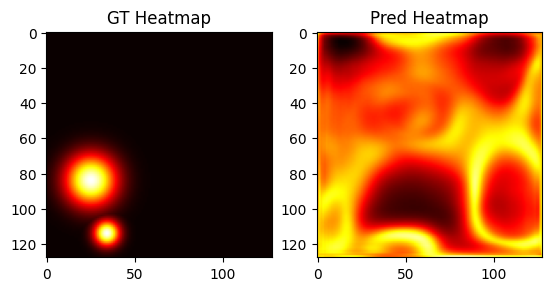


Validation loss      : 925.6759
Validation mask loss : 924.8693
Validation regr loss : 0.8066
Precision:        0.0010
Instance Recall:  0.0079
F1 Score:         0.0017
Normal Region FP: 48.35579196217494
FROC Score:       0.0017
Current Learning Rate: 5e-05
F1 Score improved from -inf to 0.0017

Epoch 2/100

Epoch 2 completed in 163.19 seconds.
Train loss : 68.3868
Train mask loss : 65.0336
Train regr loss : 3.3532

Validation loss      : 117.1767
Validation mask loss : 116.9466
Validation regr loss : 0.2302
Precision:        0.0546
Instance Recall:  0.0219
F1 Score:         0.0312
Normal Region FP: 6.48581560283688
FROC Score:       0.0196
Current Learning Rate: 5e-05
F1 Score improved from 0.0017 to 0.0312

Epoch 3/100

Epoch 3 completed in 171.39 seconds.
Train loss : 10.1835
Train mask loss : 9.1266
Train regr loss : 1.0570

Validation loss      : 20.7083
Validation mask loss : 20.6172
Validation regr loss : 0.0911
Precision:        0.0000
Instance Recall:  0.0000
F1 Score:      

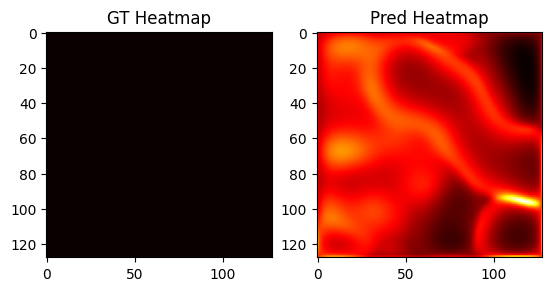


Epoch 6 completed in 163.72 seconds.
Train loss : 1.7874
Train mask loss : 1.4312
Train regr loss : 0.3563


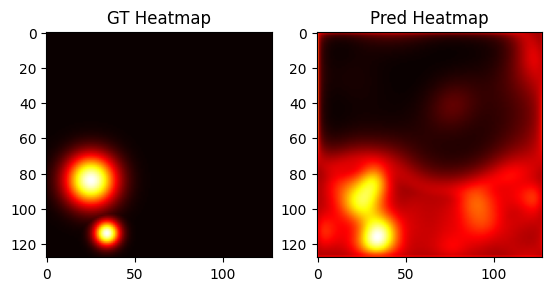


Validation loss      : 1.6541
Validation mask loss : 1.5208
Validation regr loss : 0.1333
Precision:        0.1530
Instance Recall:  0.0220
F1 Score:         0.0385
Normal Region FP: 0.0
FROC Score:       0.0118
Current Learning Rate: 5e-05
F1 Score improved from 0.0312 to 0.0385

Epoch 7/100

Epoch 7 completed in 168.71 seconds.
Train loss : 1.5096
Train mask loss : 1.2036
Train regr loss : 0.3060

Validation loss      : 1.5784
Validation mask loss : 1.4947
Validation regr loss : 0.0837
Precision:        0.0688
Instance Recall:  0.0222
F1 Score:         0.0336
Normal Region FP: 0.004728132387706856
FROC Score:       0.0262
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 8/100

Epoch 8 completed in 163.94 seconds.
Train loss : 1.4130
Train mask loss : 1.1418
Train regr loss : 0.2712

Validation loss      : 1.0510
Validation mask loss : 0.9667
Validation regr loss : 0.0843
Precision:        0.4563
Instance Recall:  0.0079
F1 Score:         0.0155
Normal Re

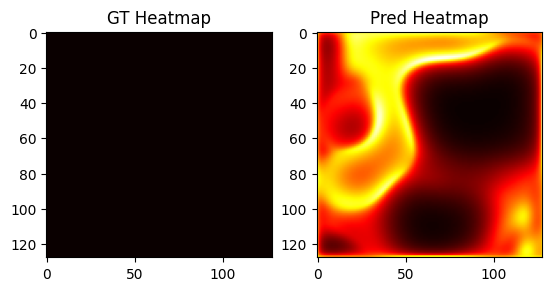


Epoch 11 completed in 167.96 seconds.
Train loss : 1.1070
Train mask loss : 0.8762
Train regr loss : 0.2308


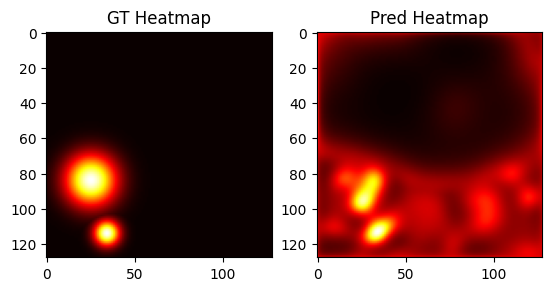


Validation loss      : 0.9212
Validation mask loss : 0.8399
Validation regr loss : 0.0813
Precision:        0.1895
Instance Recall:  0.0668
F1 Score:         0.0988
Normal Region FP: 0.004728132387706856
FROC Score:       0.0685
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 12/100

Epoch 12 completed in 164.49 seconds.
Train loss : 1.0430
Train mask loss : 0.8260
Train regr loss : 0.2170

Validation loss      : 1.0004
Validation mask loss : 0.9222
Validation regr loss : 0.0782
Precision:        0.1796
Instance Recall:  0.1378
F1 Score:         0.1559
Normal Region FP: 0.04846335697399527
FROC Score:       0.1381
Current Learning Rate: 5e-05
F1 Score improved from 0.1207 to 0.1559

Epoch 13/100

Epoch 13 completed in 167.20 seconds.
Train loss : 0.9520
Train mask loss : 0.7432
Train regr loss : 0.2089

Validation loss      : 0.7584
Validation mask loss : 0.6729
Validation regr loss : 0.0856
Precision:        0.2060
Instance Recall:  0.1267
F1 Score:     

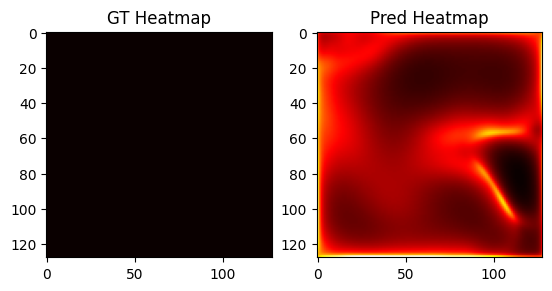


Epoch 16 completed in 170.95 seconds.
Train loss : 0.9040
Train mask loss : 0.7145
Train regr loss : 0.1895


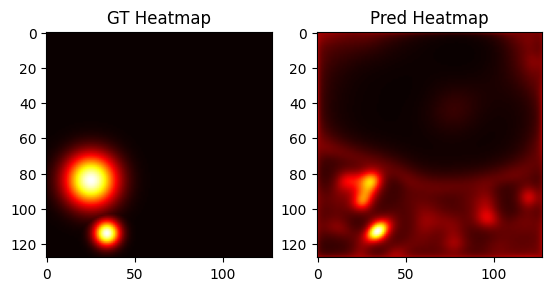


Validation loss      : 0.7150
Validation mask loss : 0.6311
Validation regr loss : 0.0838
Precision:        0.2418
Instance Recall:  0.1583
F1 Score:         0.1913
Normal Region FP: 0.0070921985815602835
FROC Score:       0.1607
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 17/100

Epoch 17 completed in 164.96 seconds.
Train loss : 0.8411
Train mask loss : 0.6602
Train regr loss : 0.1809

Validation loss      : 0.7156
Validation mask loss : 0.6259
Validation regr loss : 0.0897
Precision:        0.4829
Instance Recall:  0.3468
F1 Score:         0.4037
Normal Region FP: 0.010638297872340425
FROC Score:       0.3580
Current Learning Rate: 5e-05
F1 Score improved from 0.4021 to 0.4037

Epoch 18/100

Epoch 18 completed in 168.60 seconds.
Train loss : 0.8026
Train mask loss : 0.6254
Train regr loss : 0.1772

Validation loss      : 0.7049
Validation mask loss : 0.6246
Validation regr loss : 0.0803
Precision:        0.4862
Instance Recall:  0.2878
F1 Score:   

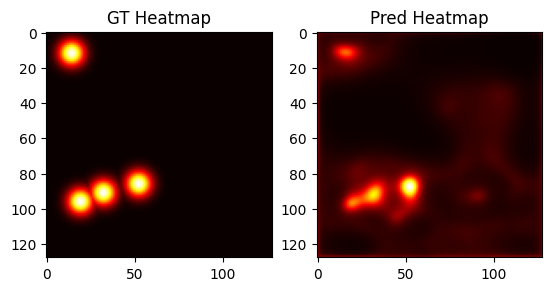


Epoch 21 completed in 168.39 seconds.
Train loss : 0.7359
Train mask loss : 0.5743
Train regr loss : 0.1615


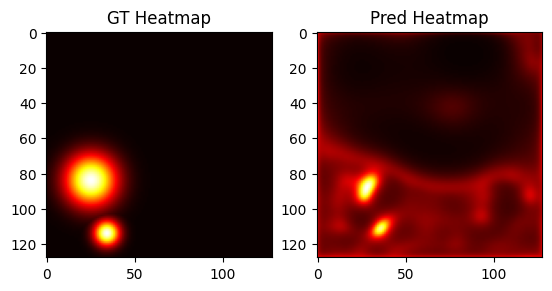


Validation loss      : 0.7289
Validation mask loss : 0.6418
Validation regr loss : 0.0871
Precision:        0.6227
Instance Recall:  0.3611
F1 Score:         0.4571
Normal Region FP: 0.013002364066193853
FROC Score:       0.4057
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 22/100

Epoch 22 completed in 164.95 seconds.
Train loss : 0.7429
Train mask loss : 0.5836
Train regr loss : 0.1594

Validation loss      : 0.7222
Validation mask loss : 0.6454
Validation regr loss : 0.0768
Precision:        0.4384
Instance Recall:  0.3018
F1 Score:         0.3575
Normal Region FP: 0.02127659574468085
FROC Score:       0.3172
Current Learning Rate: 5e-05
No improvement in F1 Score for 2 epoch(s)

Epoch 23/100

Epoch 23 completed in 165.61 seconds.
Train loss : 0.7016
Train mask loss : 0.5479
Train regr loss : 0.1537

Validation loss      : 0.7628
Validation mask loss : 0.6844
Validation regr loss : 0.0783
Precision:        0.5051
Instance Recall:  0.4422
F1 Score:   

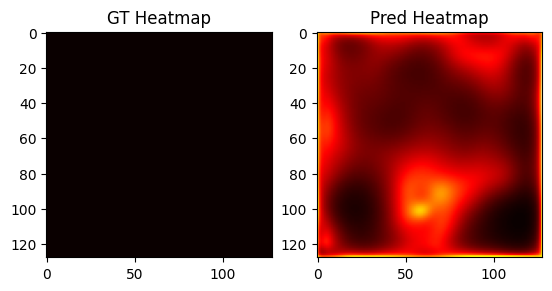


Epoch 26 completed in 163.10 seconds.
Train loss : 0.6128
Train mask loss : 0.4709
Train regr loss : 0.1419


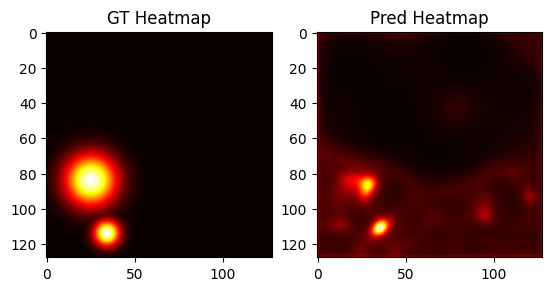


Validation loss      : 0.7931
Validation mask loss : 0.6958
Validation regr loss : 0.0974
Precision:        0.5480
Instance Recall:  0.4868
F1 Score:         0.5156
Normal Region FP: 0.037825059101654845
FROC Score:       0.5203
Current Learning Rate: 5e-05
F1 Score improved from 0.5123 to 0.5156

Epoch 27/100

Epoch 27 completed in 167.32 seconds.
Train loss : 0.5942
Train mask loss : 0.4507
Train regr loss : 0.1435

Validation loss      : 0.7376
Validation mask loss : 0.6510
Validation regr loss : 0.0866
Precision:        0.6129
Instance Recall:  0.4373
F1 Score:         0.5105
Normal Region FP: 0.016548463356973995
FROC Score:       0.4972
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 28/100

Epoch 28 completed in 163.09 seconds.
Train loss : 0.5906
Train mask loss : 0.4523
Train regr loss : 0.1382

Validation loss      : 0.8288
Validation mask loss : 0.7438
Validation regr loss : 0.0850
Precision:        0.5214
Instance Recall:  0.4767
F1 Score:    

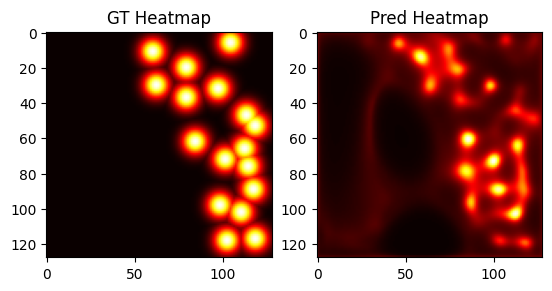


Epoch 31 completed in 163.86 seconds.
Train loss : 0.5196
Train mask loss : 0.3884
Train regr loss : 0.1312


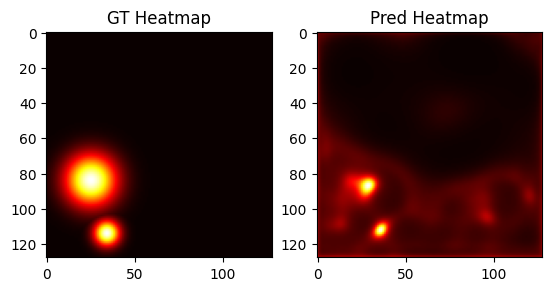


Validation loss      : 0.7246
Validation mask loss : 0.6501
Validation regr loss : 0.0745
Precision:        0.5825
Instance Recall:  0.4759
F1 Score:         0.5238
Normal Region FP: 0.022458628841607566
FROC Score:       0.5319
Current Learning Rate: 5e-06
F1 Score improved from 0.5156 to 0.5238

Epoch 32/100

Epoch 32 completed in 168.63 seconds.
Train loss : 0.5141
Train mask loss : 0.3824
Train regr loss : 0.1317

Validation loss      : 0.7274
Validation mask loss : 0.6518
Validation regr loss : 0.0756
Precision:        0.5777
Instance Recall:  0.4902
F1 Score:         0.5303
Normal Region FP: 0.013002364066193853
FROC Score:       0.5431
Current Learning Rate: 5e-06
F1 Score improved from 0.5238 to 0.5303

Epoch 33/100

Epoch 33 completed in 169.75 seconds.
Train loss : 0.4980
Train mask loss : 0.3691
Train regr loss : 0.1288

Validation loss      : 0.7446
Validation mask loss : 0.6705
Validation regr loss : 0.0741
Precision:        0.5770
Instance Recall:  0.4942
F1 Score:      

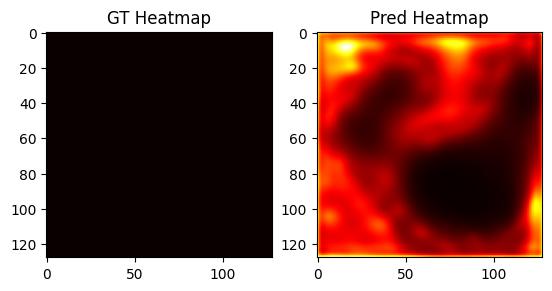


Epoch 36 completed in 163.71 seconds.
Train loss : 0.4706
Train mask loss : 0.3428
Train regr loss : 0.1279


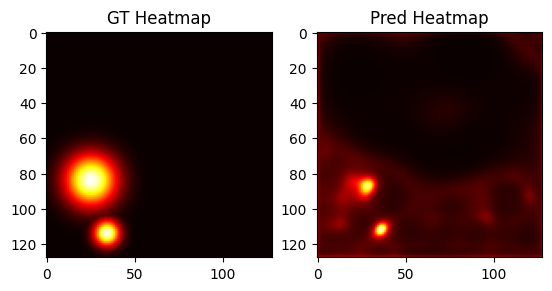


Validation loss      : 0.7636
Validation mask loss : 0.6860
Validation regr loss : 0.0776
Precision:        0.5744
Instance Recall:  0.4930
F1 Score:         0.5306
Normal Region FP: 0.016548463356973995
FROC Score:       0.5554
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 2 epoch(s)

Epoch 37/100

Epoch 37 completed in 163.70 seconds.
Train loss : 0.4773
Train mask loss : 0.3484
Train regr loss : 0.1288

Validation loss      : 0.7361
Validation mask loss : 0.6626
Validation regr loss : 0.0735
Precision:        0.6043
Instance Recall:  0.4799
F1 Score:         0.5350
Normal Region FP: 0.016548463356973995
FROC Score:       0.5565
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 3 epoch(s)

Epoch 38/100

Epoch 38 completed in 164.87 seconds.
Train loss : 0.4727
Train mask loss : 0.3437
Train regr loss : 0.1290

Validation loss      : 0.7646
Validation mask loss : 0.6841
Validation regr loss : 0.0805
Precision:        0.6034
Inst

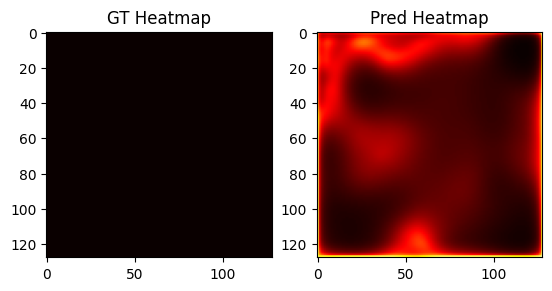


Epoch 41 completed in 164.25 seconds.
Train loss : 0.4819
Train mask loss : 0.3543
Train regr loss : 0.1277


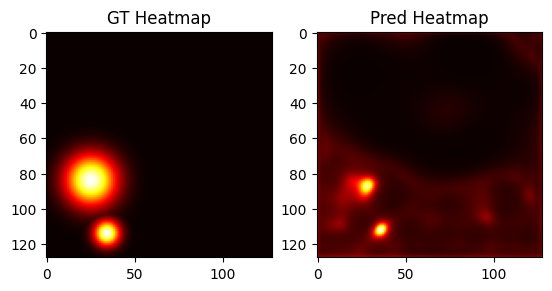


Validation loss      : 0.7354
Validation mask loss : 0.6585
Validation regr loss : 0.0769
Precision:        0.5935
Instance Recall:  0.4846
F1 Score:         0.5336
Normal Region FP: 0.009456264775413711
FROC Score:       0.5509
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 7 epoch(s)

Epoch 42/100

Epoch 42 completed in 163.26 seconds.
Train loss : 0.4707
Train mask loss : 0.3448
Train regr loss : 0.1259

Validation loss      : 0.7505
Validation mask loss : 0.6774
Validation regr loss : 0.0732
Precision:        0.5956
Instance Recall:  0.4861
F1 Score:         0.5353
Normal Region FP: 0.02009456264775414
FROC Score:       0.5578
Current Learning Rate: 1e-07
No improvement in F1 Score for 8 epoch(s)

Epoch 43/100

Epoch 43 completed in 163.29 seconds.
Train loss : 0.4898
Train mask loss : 0.3610
Train regr loss : 0.1287

Validation loss      : 0.7699
Validation mask loss : 0.6967
Validation regr loss : 0.0732
Precision:        0.5709
Instance Recall:  0.4

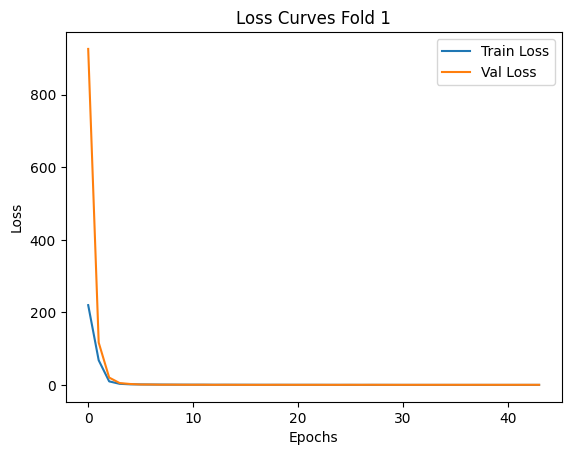


 Test Result
Precision: 0.6050
Instance Recall: 0.6055
F1 Score:  0.6052
FPs:       99.9860
FROC Score: 0.6704
Saved results to: /content/drive/MyDrive/Dissertation_Chatwipa/model_checkpoint/baseline_augmented/adamw18_checkpoints_20250710_164037/fold1/test_results.csv
==== Test Fold: fold2, Val Fold: fold3, Train Folds: ['fold1', 'fold4'] ====

Epoch 1/100


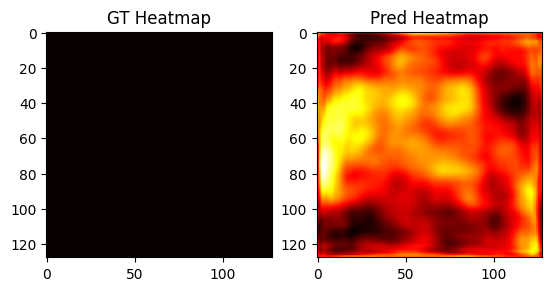


Epoch 1 completed in 171.13 seconds.
Train loss : 187.9223
Train mask loss : 181.0070
Train regr loss : 6.9152


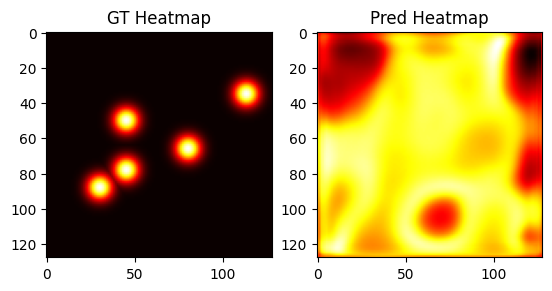


Validation loss      : 1036.6173
Validation mask loss : 1036.3931
Validation regr loss : 0.2242
Precision:        0.0022
Instance Recall:  0.0104
F1 Score:         0.0036
Normal Region FP: 25.261988304093567
FROC Score:       0.0042
Current Learning Rate: 5e-05
F1 Score improved from -inf to 0.0036

Epoch 2/100

Epoch 2 completed in 171.32 seconds.
Train loss : 38.9670
Train mask loss : 36.3411
Train regr loss : 2.6259

Validation loss      : 110.0832
Validation mask loss : 109.9478
Validation regr loss : 0.1354
Precision:        0.0000
Instance Recall:  0.0000
F1 Score:         0.0000
Normal Region FP: 2.7719298245614037
FROC Score:       0.0096
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 3/100

Epoch 3 completed in 170.82 seconds.
Train loss : 7.8698
Train mask loss : 7.0038
Train regr loss : 0.8661

Validation loss      : 23.4652
Validation mask loss : 23.3664
Validation regr loss : 0.0988
Precision:        0.0000
Instance Recall:  0.0000
F1 Score:

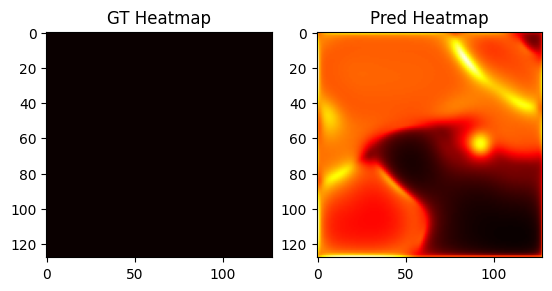


Epoch 6 completed in 172.72 seconds.
Train loss : 1.5690
Train mask loss : 1.2451
Train regr loss : 0.3239


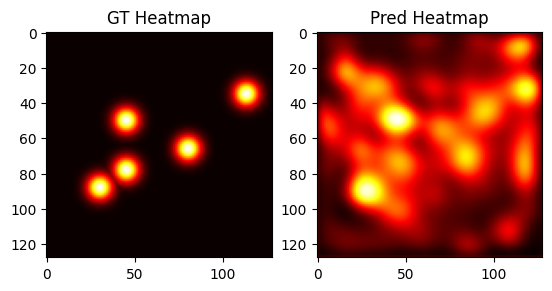


Validation loss      : 2.7963
Validation mask loss : 2.7108
Validation regr loss : 0.0855
Precision:        0.0221
Instance Recall:  0.0185
F1 Score:         0.0201
Normal Region FP: 0.09824561403508772
FROC Score:       0.0196
Current Learning Rate: 5e-05
F1 Score improved from 0.0036 to 0.0201

Epoch 7/100

Epoch 7 completed in 174.23 seconds.
Train loss : 1.3556
Train mask loss : 1.0682
Train regr loss : 0.2874

Validation loss      : 1.3158
Validation mask loss : 1.2345
Validation regr loss : 0.0813
Precision:        0.0601
Instance Recall:  0.0320
F1 Score:         0.0418
Normal Region FP: 0.031578947368421054
FROC Score:       0.0337
Current Learning Rate: 5e-05
F1 Score improved from 0.0201 to 0.0418

Epoch 8/100

Epoch 8 completed in 174.51 seconds.
Train loss : 1.3149
Train mask loss : 1.0428
Train regr loss : 0.2721

Validation loss      : 1.1302
Validation mask loss : 1.0492
Validation regr loss : 0.0810
Precision:        0.2658
Instance Recall:  0.1659
F1 Score:         0.

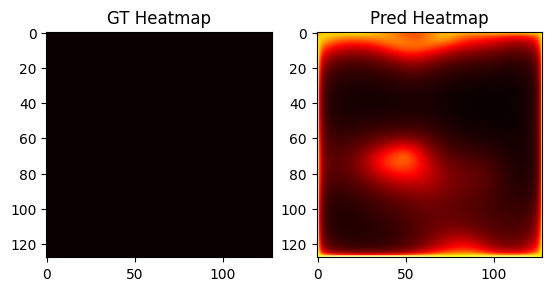


Epoch 11 completed in 170.00 seconds.
Train loss : 1.0917
Train mask loss : 0.8600
Train regr loss : 0.2317


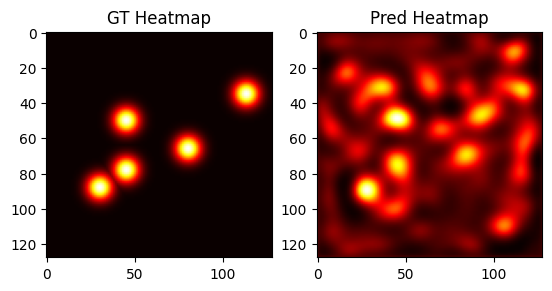


Validation loss      : 0.8006
Validation mask loss : 0.7229
Validation regr loss : 0.0778
Precision:        0.2401
Instance Recall:  0.2275
F1 Score:         0.2336
Normal Region FP: 0.012865497076023392
FROC Score:       0.2313
Current Learning Rate: 5e-05
F1 Score improved from 0.2043 to 0.2336

Epoch 12/100

Epoch 12 completed in 175.05 seconds.
Train loss : 0.9841
Train mask loss : 0.7569
Train regr loss : 0.2272

Validation loss      : 1.0809
Validation mask loss : 1.0055
Validation regr loss : 0.0754
Precision:        0.2035
Instance Recall:  0.2150
F1 Score:         0.2091
Normal Region FP: 0.07953216374269007
FROC Score:       0.2168
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 13/100

Epoch 13 completed in 170.01 seconds.
Train loss : 0.9453
Train mask loss : 0.7339
Train regr loss : 0.2115

Validation loss      : 0.6949
Validation mask loss : 0.6202
Validation regr loss : 0.0747
Precision:        0.4433
Instance Recall:  0.3664
F1 Score:     

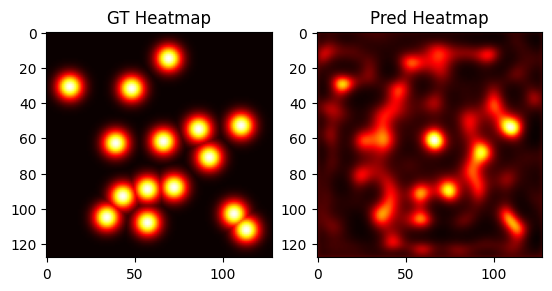


Epoch 16 completed in 172.62 seconds.
Train loss : 0.8200
Train mask loss : 0.6300
Train regr loss : 0.1900


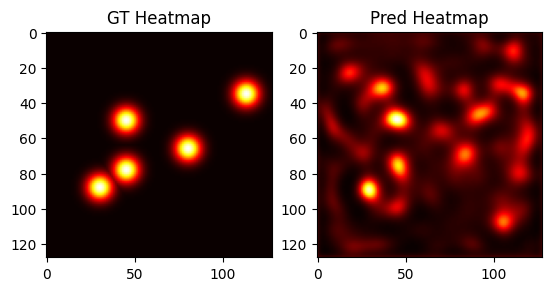


Validation loss      : 0.6316
Validation mask loss : 0.5582
Validation regr loss : 0.0735
Precision:        0.2204
Instance Recall:  0.1780
F1 Score:         0.1970
Normal Region FP: 0.012865497076023392
FROC Score:       0.1859
Current Learning Rate: 5e-05
No improvement in F1 Score for 2 epoch(s)

Epoch 17/100

Epoch 17 completed in 170.03 seconds.
Train loss : 0.8025
Train mask loss : 0.6185
Train regr loss : 0.1840

Validation loss      : 0.5692
Validation mask loss : 0.4971
Validation regr loss : 0.0721
Precision:        0.3701
Instance Recall:  0.3290
F1 Score:         0.3483
Normal Region FP: 0.00935672514619883
FROC Score:       0.3412
Current Learning Rate: 5e-05
No improvement in F1 Score for 3 epoch(s)

Epoch 18/100

Epoch 18 completed in 170.84 seconds.
Train loss : 0.7769
Train mask loss : 0.5948
Train regr loss : 0.1820

Validation loss      : 0.5288
Validation mask loss : 0.4602
Validation regr loss : 0.0686
Precision:        0.5461
Instance Recall:  0.4519
F1 Score:   

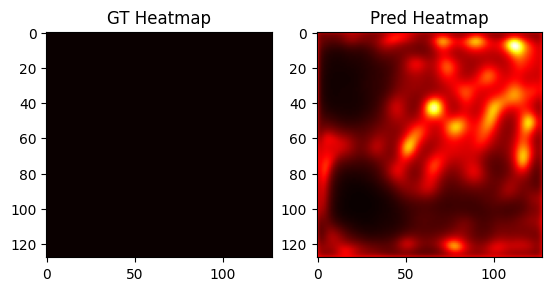


Epoch 21 completed in 170.57 seconds.
Train loss : 0.7089
Train mask loss : 0.5396
Train regr loss : 0.1694


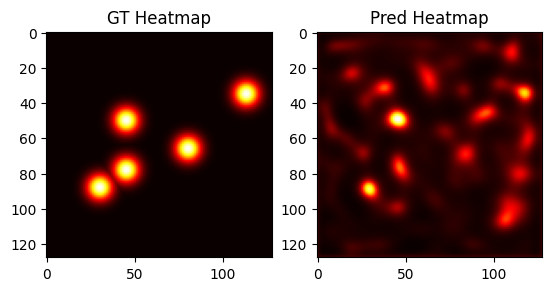


Validation loss      : 0.5527
Validation mask loss : 0.4844
Validation regr loss : 0.0684
Precision:        0.5395
Instance Recall:  0.5379
F1 Score:         0.5387
Normal Region FP: 0.02456140350877193
FROC Score:       0.5737
Current Learning Rate: 5e-05
F1 Score improved from 0.4945 to 0.5387

Epoch 22/100

Epoch 22 completed in 174.82 seconds.
Train loss : 0.6651
Train mask loss : 0.5010
Train regr loss : 0.1641

Validation loss      : 0.4790
Validation mask loss : 0.4107
Validation regr loss : 0.0683
Precision:        0.5511
Instance Recall:  0.4858
F1 Score:         0.5164
Normal Region FP: 0.0035087719298245615
FROC Score:       0.5405
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 23/100

Epoch 23 completed in 169.46 seconds.
Train loss : 0.6644
Train mask loss : 0.5007
Train regr loss : 0.1637

Validation loss      : 0.5284
Validation mask loss : 0.4608
Validation regr loss : 0.0676
Precision:        0.4245
Instance Recall:  0.4932
F1 Score:    

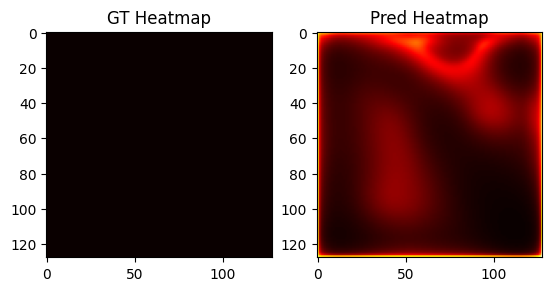


Epoch 26 completed in 170.37 seconds.
Train loss : 0.6227
Train mask loss : 0.4696
Train regr loss : 0.1532


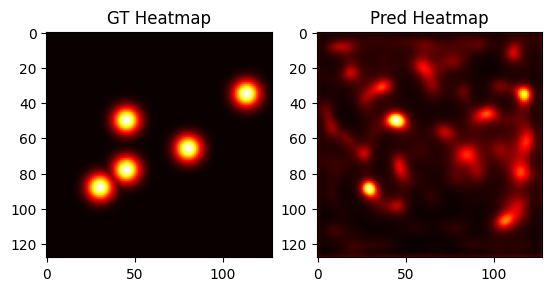


Validation loss      : 0.6144
Validation mask loss : 0.5491
Validation regr loss : 0.0652
Precision:        0.5093
Instance Recall:  0.6573
F1 Score:         0.5739
Normal Region FP: 0.06198830409356725
FROC Score:       0.7089
Current Learning Rate: 5e-05
F1 Score improved from 0.5582 to 0.5739

Epoch 27/100

Epoch 27 completed in 177.32 seconds.
Train loss : 0.5955
Train mask loss : 0.4443
Train regr loss : 0.1512

Validation loss      : 0.5292
Validation mask loss : 0.4642
Validation regr loss : 0.0650
Precision:        0.5012
Instance Recall:  0.6222
F1 Score:         0.5552
Normal Region FP: 0.03859649122807018
FROC Score:       0.6832
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 28/100

Epoch 28 completed in 171.49 seconds.
Train loss : 0.5968
Train mask loss : 0.4453
Train regr loss : 0.1515

Validation loss      : 0.5633
Validation mask loss : 0.4970
Validation regr loss : 0.0663
Precision:        0.5205
Instance Recall:  0.6771
F1 Score:      

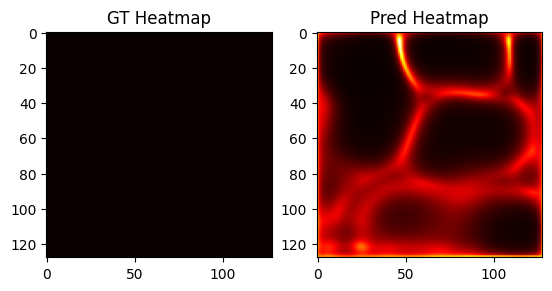


Epoch 31 completed in 170.03 seconds.
Train loss : 0.5288
Train mask loss : 0.3851
Train regr loss : 0.1436


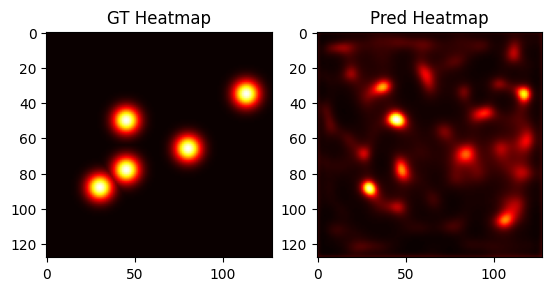


Validation loss      : 0.5122
Validation mask loss : 0.4474
Validation regr loss : 0.0647
Precision:        0.5261
Instance Recall:  0.6373
F1 Score:         0.5764
Normal Region FP: 0.028070175438596492
FROC Score:       0.7021
Current Learning Rate: 5e-06
No improvement in F1 Score for 3 epoch(s)

Epoch 32/100

Epoch 32 completed in 169.23 seconds.
Train loss : 0.5175
Train mask loss : 0.3754
Train regr loss : 0.1422

Validation loss      : 0.5052
Validation mask loss : 0.4406
Validation regr loss : 0.0647
Precision:        0.5308
Instance Recall:  0.6521
F1 Score:         0.5852
Normal Region FP: 0.023391812865497075
FROC Score:       0.7148
Current Learning Rate: 5e-06
No improvement in F1 Score for 4 epoch(s)

Epoch 33/100

Epoch 33 completed in 170.04 seconds.
Train loss : 0.5203
Train mask loss : 0.3776
Train regr loss : 0.1427

Validation loss      : 0.5358
Validation mask loss : 0.4710
Validation regr loss : 0.0648
Precision:        0.5110
Instance Recall:  0.6482
F1 Score:  

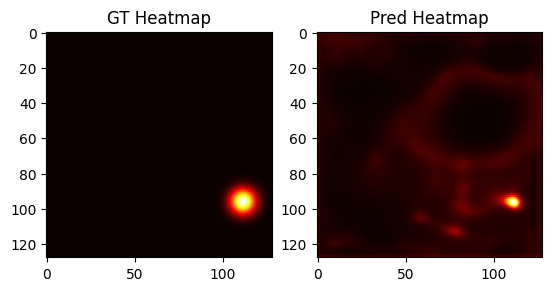


Epoch 36 completed in 170.29 seconds.
Train loss : 0.5065
Train mask loss : 0.3650
Train regr loss : 0.1415


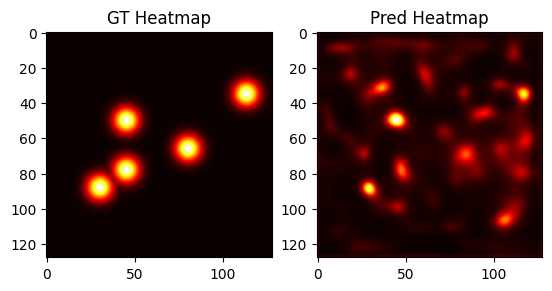


Validation loss      : 0.5210
Validation mask loss : 0.4563
Validation regr loss : 0.0647
Precision:        0.5287
Instance Recall:  0.6538
F1 Score:         0.5846
Normal Region FP: 0.021052631578947368
FROC Score:       0.7100
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 8 epoch(s)

Epoch 37/100

Epoch 37 completed in 169.69 seconds.
Train loss : 0.5188
Train mask loss : 0.3753
Train regr loss : 0.1435

Validation loss      : 0.5174
Validation mask loss : 0.4528
Validation regr loss : 0.0646
Precision:        0.5327
Instance Recall:  0.6496
F1 Score:         0.5854
Normal Region FP: 0.019883040935672516
FROC Score:       0.7050
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 9 epoch(s)

Epoch 38/100

Epoch 38 completed in 169.64 seconds.
Train loss : 0.4968
Train mask loss : 0.3580
Train regr loss : 0.1388

Validation loss      : 0.5172
Validation mask loss : 0.4529
Validation regr loss : 0.0643
Precision:        0.5410
Inst

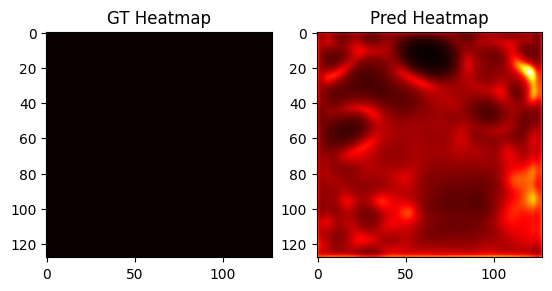


Epoch 41 completed in 171.63 seconds.
Train loss : 0.5093
Train mask loss : 0.3668
Train regr loss : 0.1425


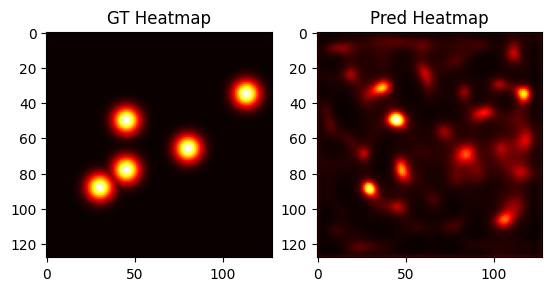


Validation loss      : 0.5323
Validation mask loss : 0.4676
Validation regr loss : 0.0647
Precision:        0.5287
Instance Recall:  0.6594
F1 Score:         0.5868
Normal Region FP: 0.023391812865497075
FROC Score:       0.7143
Current Learning Rate: 1e-07
No improvement in F1 Score for 3 epoch(s)

Epoch 42/100

Epoch 42 completed in 170.30 seconds.
Train loss : 0.5053
Train mask loss : 0.3644
Train regr loss : 0.1410

Validation loss      : 0.5655
Validation mask loss : 0.5010
Validation regr loss : 0.0644
Precision:        0.5224
Instance Recall:  0.6579
F1 Score:         0.5824
Normal Region FP: 0.042105263157894736
FROC Score:       0.7107
Current Learning Rate: 1e-07
No improvement in F1 Score for 4 epoch(s)

Epoch 43/100

Epoch 43 completed in 170.11 seconds.
Train loss : 0.5080
Train mask loss : 0.3680
Train regr loss : 0.1400

Validation loss      : 0.5534
Validation mask loss : 0.4889
Validation regr loss : 0.0644
Precision:        0.5155
Instance Recall:  0.6727
F1 Score:  

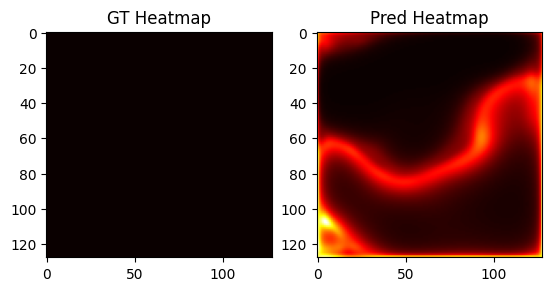


Epoch 46 completed in 169.41 seconds.
Train loss : 0.4951
Train mask loss : 0.3542
Train regr loss : 0.1409


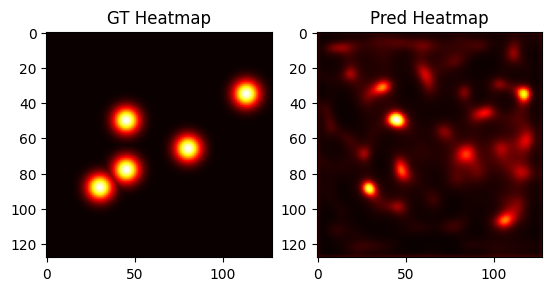


Validation loss      : 0.5080
Validation mask loss : 0.4434
Validation regr loss : 0.0646
Precision:        0.5504
Instance Recall:  0.6388
F1 Score:         0.5913
Normal Region FP: 0.023391812865497075
FROC Score:       0.7099
Current Learning Rate: 1e-07
No improvement in F1 Score for 8 epoch(s)

Epoch 47/100

Epoch 47 completed in 169.50 seconds.
Train loss : 0.5062
Train mask loss : 0.3647
Train regr loss : 0.1414

Validation loss      : 0.5272
Validation mask loss : 0.4627
Validation regr loss : 0.0645
Precision:        0.5304
Instance Recall:  0.6480
F1 Score:         0.5833
Normal Region FP: 0.023391812865497075
FROC Score:       0.7113
Current Learning Rate: 1e-07
No improvement in F1 Score for 9 epoch(s)

Epoch 48/100

Epoch 48 completed in 169.37 seconds.
Train loss : 0.5024
Train mask loss : 0.3613
Train regr loss : 0.1411

Validation loss      : 0.5495
Validation mask loss : 0.4850
Validation regr loss : 0.0645
Precision:        0.5374
Instance Recall:  0.6575
F1 Score:  

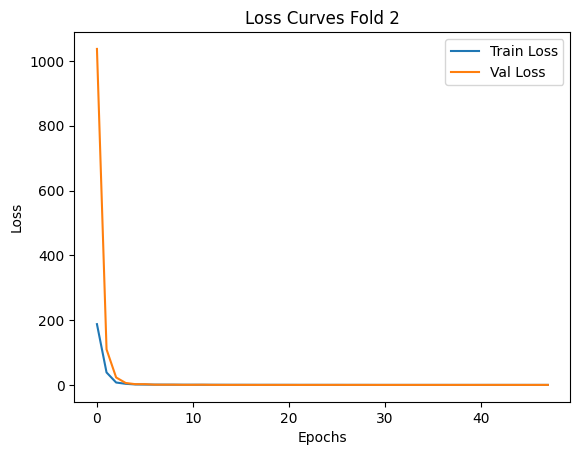


 Test Result
Precision: 0.5635
Instance Recall: 0.5601
F1 Score:  0.5618
FPs:       99.9764
FROC Score: 0.6429
Saved results to: /content/drive/MyDrive/Dissertation_Chatwipa/model_checkpoint/baseline_augmented/adamw18_checkpoints_20250710_164037/fold2/test_results.csv
==== Test Fold: fold3, Val Fold: fold4, Train Folds: ['fold1', 'fold2'] ====

Epoch 1/100


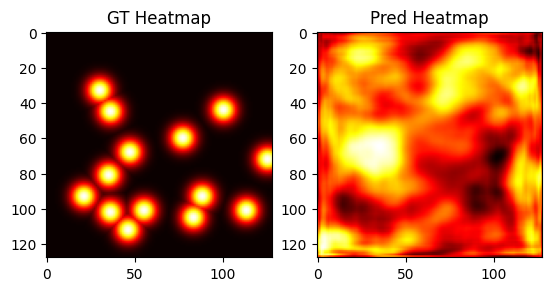


Epoch 1 completed in 175.00 seconds.
Train loss : 304.9322
Train mask loss : 297.1766
Train regr loss : 7.7556


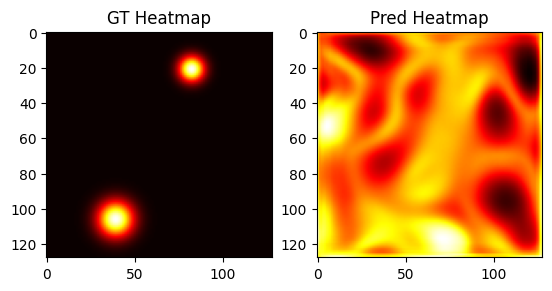


Validation loss      : 2462.5470
Validation mask loss : 2462.2048
Validation regr loss : 0.3421
Precision:        0.0008
Instance Recall:  0.0059
F1 Score:         0.0014
Normal Region FP: 42.28250591016548
FROC Score:       0.0015
Current Learning Rate: 5e-05
F1 Score improved from -inf to 0.0014

Epoch 2/100

Epoch 2 completed in 175.13 seconds.
Train loss : 64.8352
Train mask loss : 61.2525
Train regr loss : 3.5827

Validation loss      : 199.1768
Validation mask loss : 198.9753
Validation regr loss : 0.2014
Precision:        0.0036
Instance Recall:  0.0121
F1 Score:         0.0055
Normal Region FP: 16.321513002364068
FROC Score:       0.0069
Current Learning Rate: 5e-05
F1 Score improved from 0.0014 to 0.0055

Epoch 3/100

Epoch 3 completed in 178.92 seconds.
Train loss : 12.9670
Train mask loss : 11.8054
Train regr loss : 1.1616

Validation loss      : 35.1846
Validation mask loss : 35.0691
Validation regr loss : 0.1155
Precision:        0.0000
Instance Recall:  0.0000
F1 Score: 

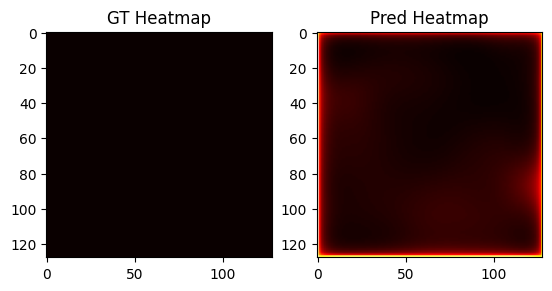


Epoch 6 completed in 174.40 seconds.
Train loss : 1.6672
Train mask loss : 1.3449
Train regr loss : 0.3223


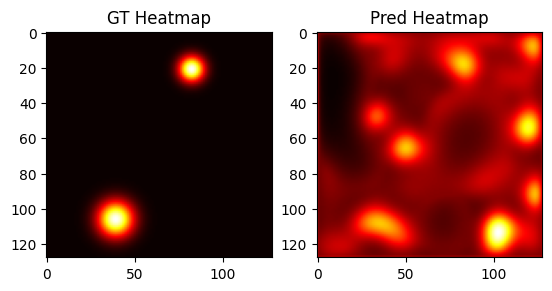


Validation loss      : 3.1894
Validation mask loss : 3.1012
Validation regr loss : 0.0882
Precision:        0.0018
Instance Recall:  0.0008
F1 Score:         0.0011
Normal Region FP: 0.10401891252955082
FROC Score:       0.0008
Current Learning Rate: 5e-05
No improvement in F1 Score for 4 epoch(s)

Epoch 7/100

Epoch 7 completed in 175.17 seconds.
Train loss : 1.4349
Train mask loss : 1.1394
Train regr loss : 0.2956

Validation loss      : 1.2792
Validation mask loss : 1.1959
Validation regr loss : 0.0833
Precision:        0.2687
Instance Recall:  0.0213
F1 Score:         0.0395
Normal Region FP: 0.001182033096926714
FROC Score:       0.0355
Current Learning Rate: 5e-05
F1 Score improved from 0.0055 to 0.0395

Epoch 8/100

Epoch 8 completed in 179.50 seconds.
Train loss : 1.2989
Train mask loss : 1.0400
Train regr loss : 0.2589

Validation loss      : 1.6864
Validation mask loss : 1.6011
Validation regr loss : 0.0854
Precision:        0.0619
Instance Recall:  0.0451
F1 Score:         

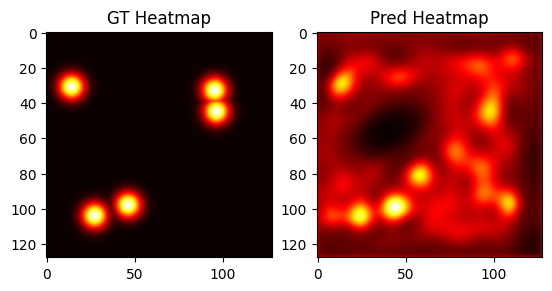


Epoch 11 completed in 181.72 seconds.
Train loss : 1.0855
Train mask loss : 0.8609
Train regr loss : 0.2246


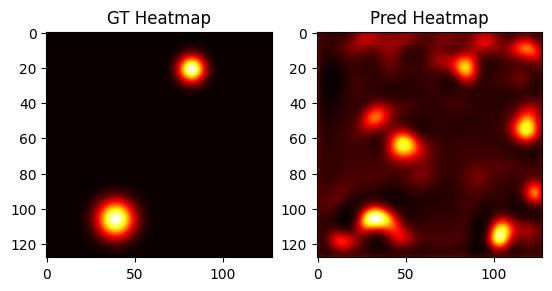


Validation loss      : 1.3460
Validation mask loss : 1.2677
Validation regr loss : 0.0784
Precision:        0.2621
Instance Recall:  0.2355
F1 Score:         0.2481
Normal Region FP: 0.08156028368794327
FROC Score:       0.2377
Current Learning Rate: 5e-05
F1 Score improved from 0.1086 to 0.2481

Epoch 12/100

Epoch 12 completed in 181.61 seconds.
Train loss : 0.9853
Train mask loss : 0.7739
Train regr loss : 0.2113

Validation loss      : 0.8413
Validation mask loss : 0.7638
Validation regr loss : 0.0775
Precision:        0.1884
Instance Recall:  0.1555
F1 Score:         0.1704
Normal Region FP: 0.030732860520094562
FROC Score:       0.1576
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 13/100

Epoch 13 completed in 175.99 seconds.
Train loss : 0.9547
Train mask loss : 0.7518
Train regr loss : 0.2028

Validation loss      : 0.7878
Validation mask loss : 0.7086
Validation regr loss : 0.0793
Precision:        0.1640
Instance Recall:  0.0755
F1 Score:     

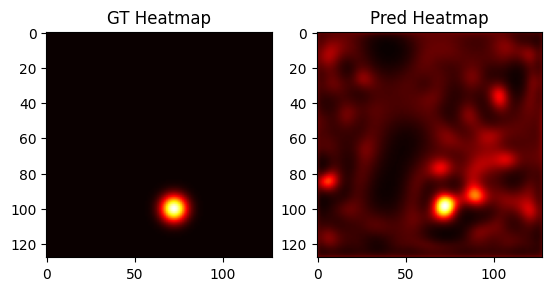


Epoch 16 completed in 181.71 seconds.
Train loss : 0.8203
Train mask loss : 0.6399
Train regr loss : 0.1804


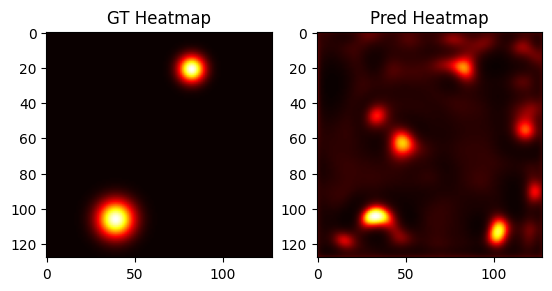


Validation loss      : 1.6042
Validation mask loss : 1.5324
Validation regr loss : 0.0718
Precision:        0.3657
Instance Recall:  0.4462
F1 Score:         0.4020
Normal Region FP: 0.21749408983451538
FROC Score:       0.4492
Current Learning Rate: 5e-05
F1 Score improved from 0.3551 to 0.4020

Epoch 17/100

Epoch 17 completed in 180.38 seconds.
Train loss : 0.8247
Train mask loss : 0.6418
Train regr loss : 0.1829

Validation loss      : 1.2318
Validation mask loss : 1.1593
Validation regr loss : 0.0725
Precision:        0.3327
Instance Recall:  0.4120
F1 Score:         0.3681
Normal Region FP: 0.11938534278959811
FROC Score:       0.4158
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 18/100

Epoch 18 completed in 176.11 seconds.
Train loss : 0.7636
Train mask loss : 0.5909
Train regr loss : 0.1727

Validation loss      : 0.7716
Validation mask loss : 0.7002
Validation regr loss : 0.0714
Precision:        0.3723
Instance Recall:  0.3303
F1 Score:      

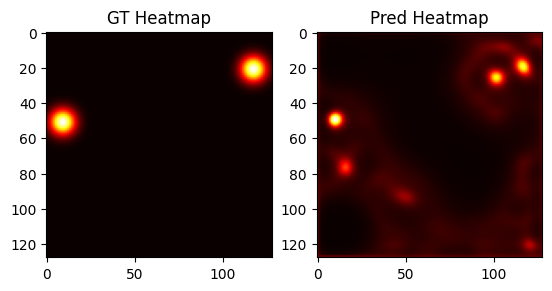


Epoch 21 completed in 176.95 seconds.
Train loss : 0.6858
Train mask loss : 0.5236
Train regr loss : 0.1622


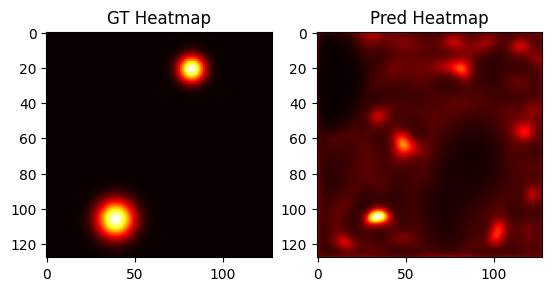


Validation loss      : 0.7447
Validation mask loss : 0.6724
Validation regr loss : 0.0723
Precision:        0.3458
Instance Recall:  0.3266
F1 Score:         0.3359
Normal Region FP: 0.030732860520094562
FROC Score:       0.3346
Current Learning Rate: 5e-05
No improvement in F1 Score for 2 epoch(s)

Epoch 22/100

Epoch 22 completed in 176.06 seconds.
Train loss : 0.6555
Train mask loss : 0.4978
Train regr loss : 0.1577

Validation loss      : 0.7454
Validation mask loss : 0.6764
Validation regr loss : 0.0690
Precision:        0.3704
Instance Recall:  0.3455
F1 Score:         0.3575
Normal Region FP: 0.016548463356973995
FROC Score:       0.3611
Current Learning Rate: 5e-05
No improvement in F1 Score for 3 epoch(s)

Epoch 23/100

Epoch 23 completed in 176.34 seconds.
Train loss : 0.6462
Train mask loss : 0.4915
Train regr loss : 0.1548

Validation loss      : 0.7188
Validation mask loss : 0.6481
Validation regr loss : 0.0707
Precision:        0.4037
Instance Recall:  0.2786
F1 Score:  

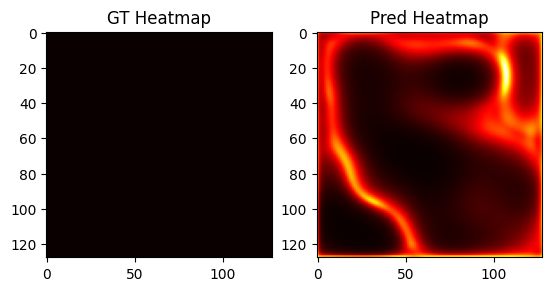


Epoch 26 completed in 180.63 seconds.
Train loss : 0.5926
Train mask loss : 0.4479
Train regr loss : 0.1448


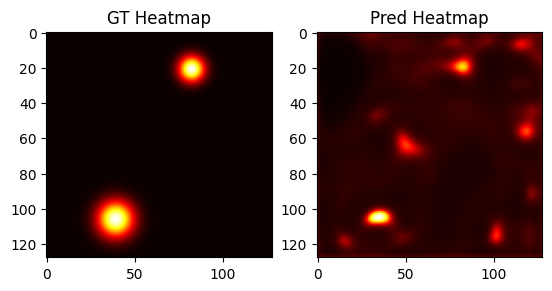


Validation loss      : 1.1190
Validation mask loss : 1.0528
Validation regr loss : 0.0661
Precision:        0.4540
Instance Recall:  0.5616
F1 Score:         0.5021
Normal Region FP: 0.09810874704491726
FROC Score:       0.5985
Current Learning Rate: 5e-05
F1 Score improved from 0.4463 to 0.5021

Epoch 27/100

Epoch 27 completed in 180.17 seconds.
Train loss : 0.5737
Train mask loss : 0.4328
Train regr loss : 0.1409

Validation loss      : 0.9320
Validation mask loss : 0.8648
Validation regr loss : 0.0672
Precision:        0.4906
Instance Recall:  0.4452
F1 Score:         0.4668
Normal Region FP: 0.027186761229314422
FROC Score:       0.4847
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 28/100

Epoch 28 completed in 176.19 seconds.
Train loss : 0.5836
Train mask loss : 0.4444
Train regr loss : 0.1392

Validation loss      : 1.1317
Validation mask loss : 1.0658
Validation regr loss : 0.0658
Precision:        0.4371
Instance Recall:  0.5550
F1 Score:     

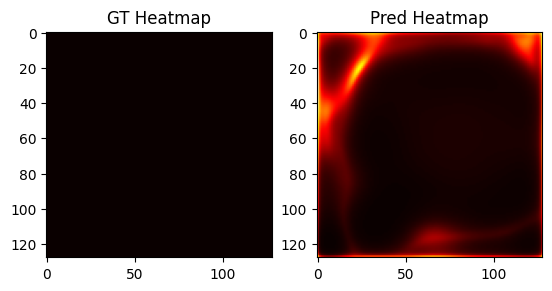


Epoch 31 completed in 175.82 seconds.
Train loss : 0.5001
Train mask loss : 0.3680
Train regr loss : 0.1322


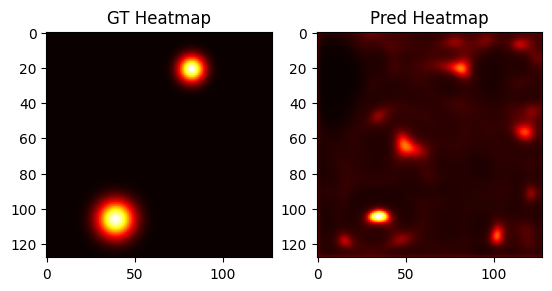


Validation loss      : 0.9179
Validation mask loss : 0.8517
Validation regr loss : 0.0662
Precision:        0.4699
Instance Recall:  0.5205
F1 Score:         0.4939
Normal Region FP: 0.037825059101654845
FROC Score:       0.5623
Current Learning Rate: 5e-06
No improvement in F1 Score for 5 epoch(s)

Epoch 32/100

Epoch 32 completed in 176.25 seconds.
Train loss : 0.4876
Train mask loss : 0.3555
Train regr loss : 0.1321

Validation loss      : 0.9503
Validation mask loss : 0.8848
Validation regr loss : 0.0655
Precision:        0.4624
Instance Recall:  0.5289
F1 Score:         0.4934
Normal Region FP: 0.031914893617021274
FROC Score:       0.5688
Current Learning Rate: 5e-06
No improvement in F1 Score for 6 epoch(s)

Epoch 33/100

Epoch 33 completed in 176.15 seconds.
Train loss : 0.4756
Train mask loss : 0.3460
Train regr loss : 0.1296

Validation loss      : 0.9047
Validation mask loss : 0.8391
Validation regr loss : 0.0657
Precision:        0.4754
Instance Recall:  0.5203
F1 Score:  

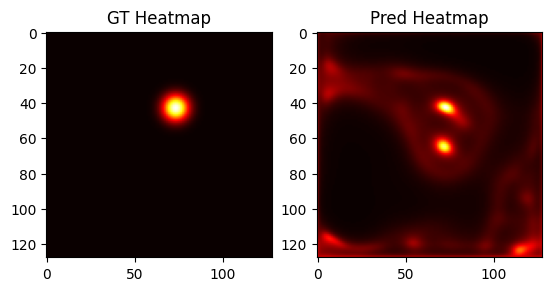


Epoch 36 completed in 181.03 seconds.
Train loss : 0.4828
Train mask loss : 0.3539
Train regr loss : 0.1289


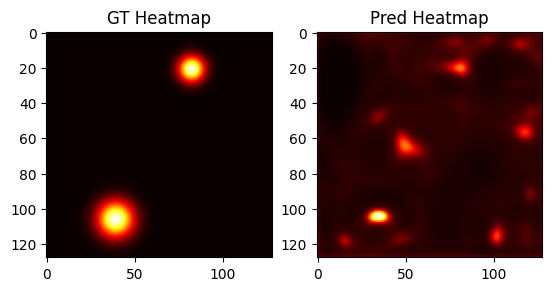


Validation loss      : 0.8403
Validation mask loss : 0.7746
Validation regr loss : 0.0658
Precision:        0.4938
Instance Recall:  0.5098
F1 Score:         0.5017
Normal Region FP: 0.028368794326241134
FROC Score:       0.5629
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 1 epoch(s)

Epoch 37/100

Epoch 37 completed in 176.08 seconds.
Train loss : 0.4770
Train mask loss : 0.3470
Train regr loss : 0.1300

Validation loss      : 0.9175
Validation mask loss : 0.8522
Validation regr loss : 0.0653
Precision:        0.4801
Instance Recall:  0.5259
F1 Score:         0.5020
Normal Region FP: 0.04964539007092199
FROC Score:       0.5685
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 2 epoch(s)

Epoch 38/100

Epoch 38 completed in 176.16 seconds.
Train loss : 0.4636
Train mask loss : 0.3352
Train regr loss : 0.1284

Validation loss      : 0.8842
Validation mask loss : 0.8187
Validation regr loss : 0.0656
Precision:        0.4957
Insta

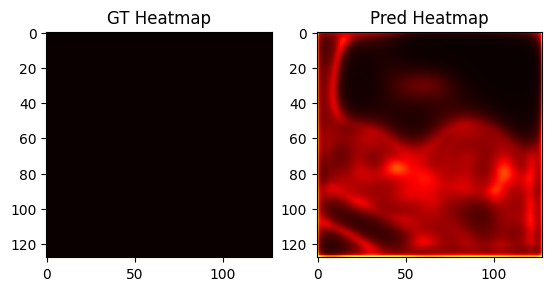


Epoch 41 completed in 177.77 seconds.
Train loss : 0.4628
Train mask loss : 0.3335
Train regr loss : 0.1293


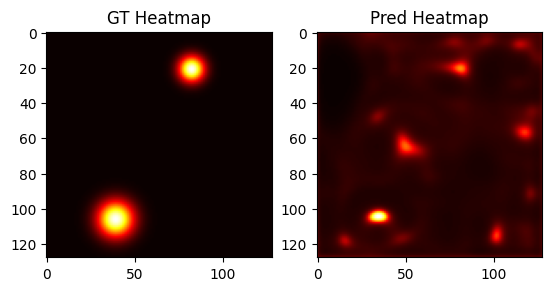


Validation loss      : 0.8293
Validation mask loss : 0.7636
Validation regr loss : 0.0657
Precision:        0.4889
Instance Recall:  0.5109
F1 Score:         0.4996
Normal Region FP: 0.037825059101654845
FROC Score:       0.5603
Current Learning Rate: 1e-07
No improvement in F1 Score for 3 epoch(s)

Epoch 42/100

Epoch 42 completed in 175.74 seconds.
Train loss : 0.4737
Train mask loss : 0.3448
Train regr loss : 0.1289

Validation loss      : 0.8877
Validation mask loss : 0.8221
Validation regr loss : 0.0656
Precision:        0.4816
Instance Recall:  0.5195
F1 Score:         0.4999
Normal Region FP: 0.034278959810874705
FROC Score:       0.5664
Current Learning Rate: 1e-07
No improvement in F1 Score for 4 epoch(s)

Epoch 43/100

Epoch 43 completed in 176.72 seconds.
Train loss : 0.4702
Train mask loss : 0.3401
Train regr loss : 0.1301

Validation loss      : 0.8392
Validation mask loss : 0.7729
Validation regr loss : 0.0663
Precision:        0.4882
Instance Recall:  0.5105
F1 Score:  

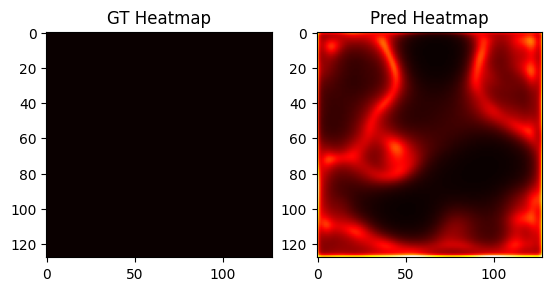


Epoch 46 completed in 175.90 seconds.
Train loss : 0.4704
Train mask loss : 0.3400
Train regr loss : 0.1304


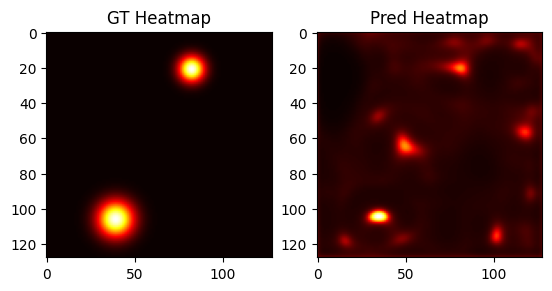


Validation loss      : 0.8546
Validation mask loss : 0.7885
Validation regr loss : 0.0661
Precision:        0.4970
Instance Recall:  0.5174
F1 Score:         0.5070
Normal Region FP: 0.024822695035460994
FROC Score:       0.5714
Current Learning Rate: 1e-07
No improvement in F1 Score for 8 epoch(s)

Epoch 47/100

Epoch 47 completed in 178.24 seconds.
Train loss : 0.4740
Train mask loss : 0.3430
Train regr loss : 0.1309

Validation loss      : 0.8865
Validation mask loss : 0.8208
Validation regr loss : 0.0658
Precision:        0.4826
Instance Recall:  0.5261
F1 Score:         0.5034
Normal Region FP: 0.03546099290780142
FROC Score:       0.5732
Current Learning Rate: 1e-07
No improvement in F1 Score for 9 epoch(s)

Epoch 48/100

Epoch 48 completed in 176.10 seconds.
Train loss : 0.4488
Train mask loss : 0.3214
Train regr loss : 0.1274

Validation loss      : 0.8959
Validation mask loss : 0.8306
Validation regr loss : 0.0653
Precision:        0.4783
Instance Recall:  0.5287
F1 Score:   

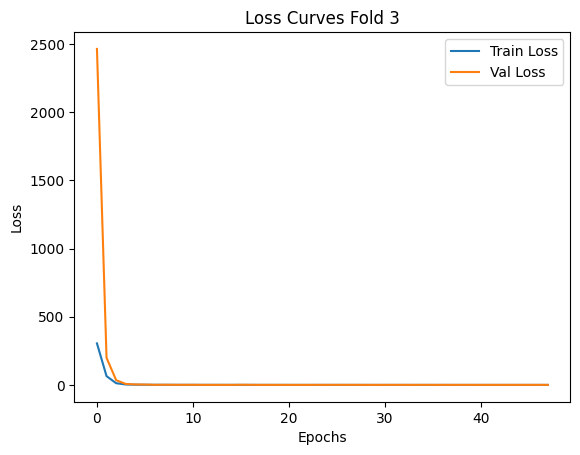


 Test Result
Precision: 0.5340
Instance Recall: 0.6286
F1 Score:  0.5775
FPs:       99.9474
FROC Score: 0.6872
Saved results to: /content/drive/MyDrive/Dissertation_Chatwipa/model_checkpoint/baseline_augmented/adamw18_checkpoints_20250710_164037/fold3/test_results.csv
==== Test Fold: fold4, Val Fold: fold1, Train Folds: ['fold2', 'fold3'] ====

Epoch 1/100


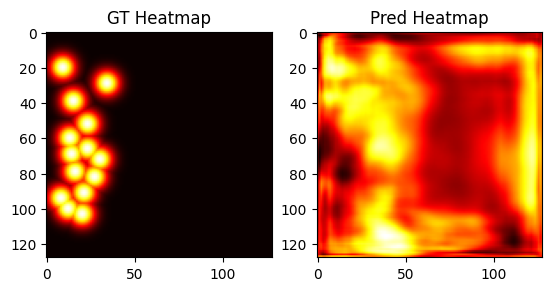


Epoch 1 completed in 167.47 seconds.
Train loss : 249.7092
Train mask loss : 241.5452
Train regr loss : 8.1640


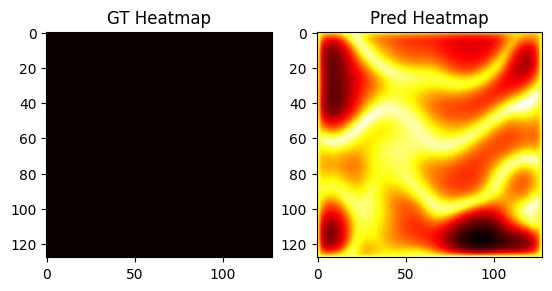


Validation loss      : 935.3640
Validation mask loss : 935.0218
Validation regr loss : 0.3422
Precision:        0.0009
Instance Recall:  0.0071
F1 Score:         0.0016
Normal Region FP: 52.38947368421053
FROC Score:       0.0015
Current Learning Rate: 5e-05
F1 Score improved from -inf to 0.0016

Epoch 2/100

Epoch 2 completed in 167.48 seconds.
Train loss : 42.6477
Train mask loss : 39.6843
Train regr loss : 2.9633

Validation loss      : 94.0952
Validation mask loss : 93.9554
Validation regr loss : 0.1398
Precision:        0.0000
Instance Recall:  0.0000
F1 Score:         0.0000
Normal Region FP: 4.249122807017544
FROC Score:       0.0024
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 3/100

Epoch 3 completed in 169.08 seconds.
Train loss : 9.4936
Train mask loss : 8.5950
Train regr loss : 0.8986

Validation loss      : 16.9218
Validation mask loss : 16.8270
Validation regr loss : 0.0948
Precision:        0.0000
Instance Recall:  0.0000
F1 Score:      

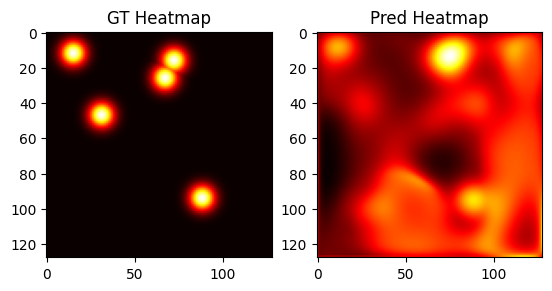


Epoch 6 completed in 167.71 seconds.
Train loss : 1.5795
Train mask loss : 1.2638
Train regr loss : 0.3157


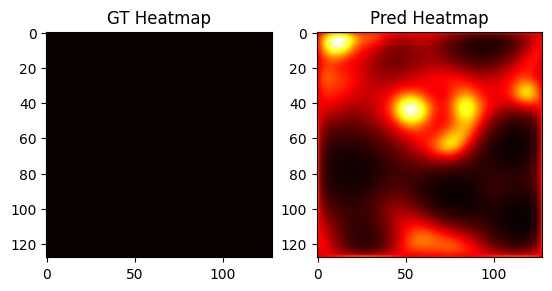


Validation loss      : 2.3539
Validation mask loss : 2.2626
Validation regr loss : 0.0913
Precision:        0.0023
Instance Recall:  0.0010
F1 Score:         0.0014
Normal Region FP: 0.014035087719298246
FROC Score:       0.0011
Current Learning Rate: 5e-05
No improvement in F1 Score for 5 epoch(s)

Epoch 7/100

Epoch 7 completed in 167.12 seconds.
Train loss : 1.4271
Train mask loss : 1.1474
Train regr loss : 0.2797

Validation loss      : 1.0766
Validation mask loss : 0.9874
Validation regr loss : 0.0892
Precision:        0.0344
Instance Recall:  0.0163
F1 Score:         0.0221
Normal Region FP: 0.0035087719298245615
FROC Score:       0.0164
Current Learning Rate: 5e-05
F1 Score improved from 0.0016 to 0.0221

Epoch 8/100

Epoch 8 completed in 173.22 seconds.
Train loss : 1.3096
Train mask loss : 1.0560
Train regr loss : 0.2535

Validation loss      : 1.3587
Validation mask loss : 1.2649
Validation regr loss : 0.0939
Precision:        0.0279
Instance Recall:  0.0149
F1 Score:       

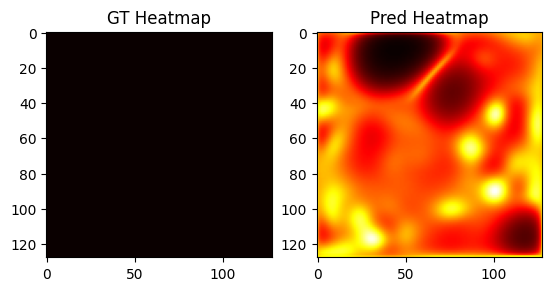


Epoch 11 completed in 167.46 seconds.
Train loss : 1.1360
Train mask loss : 0.9238
Train regr loss : 0.2122


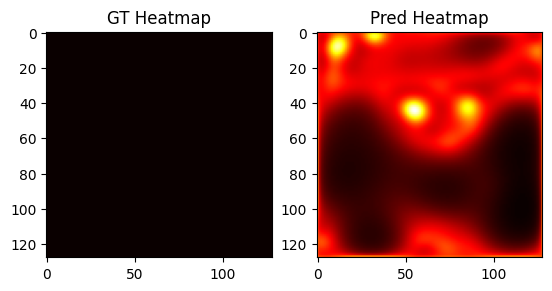


Validation loss      : 0.7620
Validation mask loss : 0.6760
Validation regr loss : 0.0860
Precision:        0.1027
Instance Recall:  0.0630
F1 Score:         0.0781
Normal Region FP: 0.005847953216374269
FROC Score:       0.0634
Current Learning Rate: 5e-05
No improvement in F1 Score for 2 epoch(s)

Epoch 12/100

Epoch 12 completed in 166.20 seconds.
Train loss : 1.0284
Train mask loss : 0.8227
Train regr loss : 0.2057

Validation loss      : 0.8001
Validation mask loss : 0.7135
Validation regr loss : 0.0866
Precision:        0.0539
Instance Recall:  0.0390
F1 Score:         0.0453
Normal Region FP: 0.008187134502923977
FROC Score:       0.0391
Current Learning Rate: 5e-05
No improvement in F1 Score for 3 epoch(s)

Epoch 13/100

Epoch 13 completed in 166.79 seconds.
Train loss : 0.9701
Train mask loss : 0.7744
Train regr loss : 0.1957

Validation loss      : 0.7823
Validation mask loss : 0.6982
Validation regr loss : 0.0841
Precision:        0.2146
Instance Recall:  0.1622
F1 Score:  

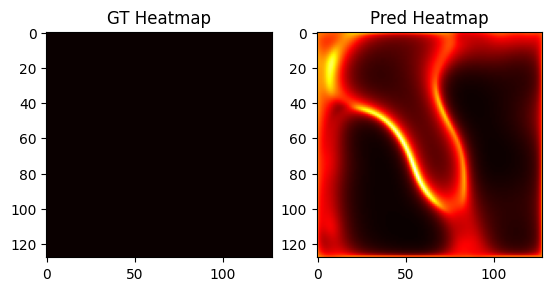


Epoch 16 completed in 168.43 seconds.
Train loss : 0.8711
Train mask loss : 0.6933
Train regr loss : 0.1778


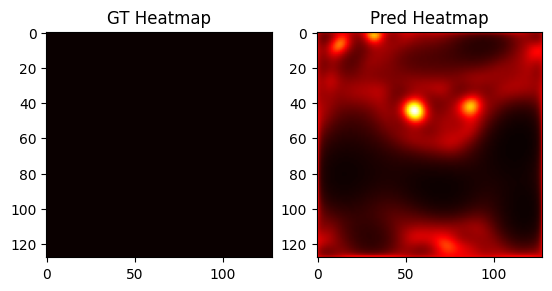


Validation loss      : 0.7021
Validation mask loss : 0.6216
Validation regr loss : 0.0805
Precision:        0.3072
Instance Recall:  0.3204
F1 Score:         0.3137
Normal Region FP: 0.03508771929824561
FROC Score:       0.3233
Current Learning Rate: 5e-05
F1 Score improved from 0.2157 to 0.3137

Epoch 17/100

Epoch 17 completed in 172.26 seconds.
Train loss : 0.8427
Train mask loss : 0.6727
Train regr loss : 0.1700

Validation loss      : 0.5814
Validation mask loss : 0.5042
Validation regr loss : 0.0772
Precision:        0.4206
Instance Recall:  0.4082
F1 Score:         0.4143
Normal Region FP: 0.010526315789473684
FROC Score:       0.4217
Current Learning Rate: 5e-05
F1 Score improved from 0.3137 to 0.4143

Epoch 18/100

Epoch 18 completed in 172.45 seconds.
Train loss : 0.7620
Train mask loss : 0.5984
Train regr loss : 0.1636

Validation loss      : 0.7433
Validation mask loss : 0.6667
Validation regr loss : 0.0766
Precision:        0.3592
Instance Recall:  0.3537
F1 Score:       

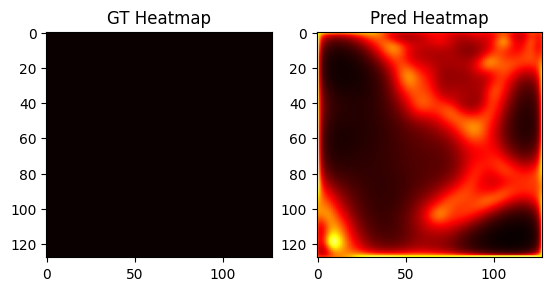


Epoch 21 completed in 168.29 seconds.
Train loss : 0.6946
Train mask loss : 0.5437
Train regr loss : 0.1509


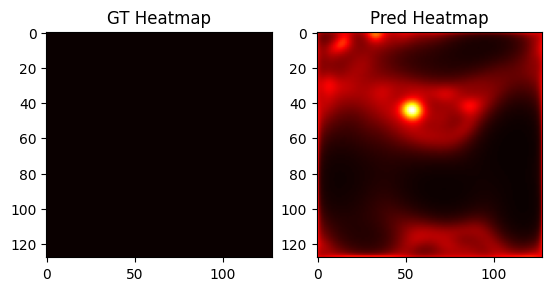


Validation loss      : 0.6142
Validation mask loss : 0.5382
Validation regr loss : 0.0760
Precision:        0.5011
Instance Recall:  0.5062
F1 Score:         0.5037
Normal Region FP: 0.0304093567251462
FROC Score:       0.5174
Current Learning Rate: 5e-05
F1 Score improved from 0.4143 to 0.5037

Epoch 22/100

Epoch 22 completed in 171.81 seconds.
Train loss : 0.6627
Train mask loss : 0.5145
Train regr loss : 0.1482

Validation loss      : 0.5885
Validation mask loss : 0.5118
Validation regr loss : 0.0768
Precision:        0.3856
Instance Recall:  0.3100
F1 Score:         0.3437
Normal Region FP: 0.022222222222222223
FROC Score:       0.3234
Current Learning Rate: 5e-05
No improvement in F1 Score for 1 epoch(s)

Epoch 23/100

Epoch 23 completed in 168.25 seconds.
Train loss : 0.6645
Train mask loss : 0.5211
Train regr loss : 0.1434

Validation loss      : 0.6504
Validation mask loss : 0.5779
Validation regr loss : 0.0726
Precision:        0.4808
Instance Recall:  0.5637
F1 Score:      

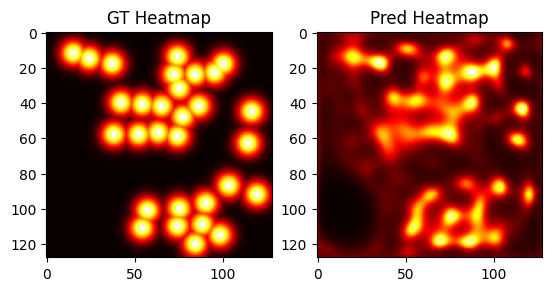


Epoch 26 completed in 172.00 seconds.
Train loss : 0.5648
Train mask loss : 0.4285
Train regr loss : 0.1363


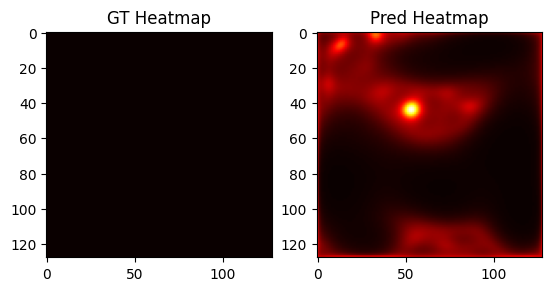


Validation loss      : 0.5713
Validation mask loss : 0.4994
Validation regr loss : 0.0718
Precision:        0.5027
Instance Recall:  0.5458
F1 Score:         0.5234
Normal Region FP: 0.03391812865497076
FROC Score:       0.5678
Current Learning Rate: 5e-06
No improvement in F1 Score for 1 epoch(s)

Epoch 27/100

Epoch 27 completed in 167.93 seconds.
Train loss : 0.5316
Train mask loss : 0.4007
Train regr loss : 0.1309

Validation loss      : 0.5601
Validation mask loss : 0.4877
Validation regr loss : 0.0723
Precision:        0.4937
Instance Recall:  0.5243
F1 Score:         0.5085
Normal Region FP: 0.022222222222222223
FROC Score:       0.5462
Current Learning Rate: 5e-06
No improvement in F1 Score for 2 epoch(s)

Epoch 28/100

Epoch 28 completed in 167.73 seconds.
Train loss : 0.5502
Train mask loss : 0.4168
Train regr loss : 0.1334

Validation loss      : 0.5549
Validation mask loss : 0.4837
Validation regr loss : 0.0713
Precision:        0.5387
Instance Recall:  0.5782
F1 Score:   

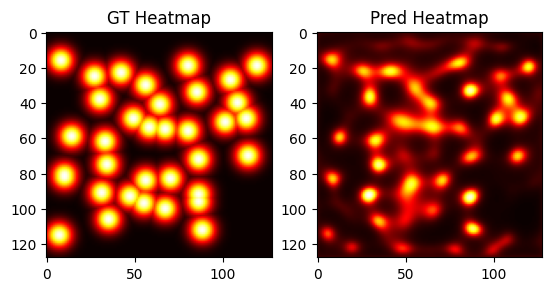


Epoch 31 completed in 168.70 seconds.
Train loss : 0.5104
Train mask loss : 0.3815
Train regr loss : 0.1289


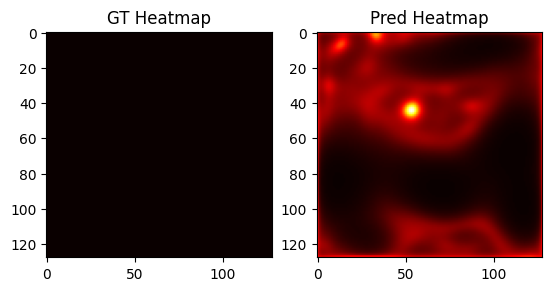


Validation loss      : 0.5633
Validation mask loss : 0.4929
Validation regr loss : 0.0704
Precision:        0.5296
Instance Recall:  0.5854
F1 Score:         0.5561
Normal Region FP: 0.031578947368421054
FROC Score:       0.6138
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 2 epoch(s)

Epoch 32/100

Epoch 32 completed in 167.64 seconds.
Train loss : 0.5283
Train mask loss : 0.3995
Train regr loss : 0.1288

Validation loss      : 0.5865
Validation mask loss : 0.5160
Validation regr loss : 0.0706
Precision:        0.5347
Instance Recall:  0.5873
F1 Score:         0.5597
Normal Region FP: 0.03742690058479532
FROC Score:       0.6148
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 3 epoch(s)

Epoch 33/100

Epoch 33 completed in 169.24 seconds.
Train loss : 0.5232
Train mask loss : 0.3935
Train regr loss : 0.1296

Validation loss      : 0.5719
Validation mask loss : 0.5010
Validation regr loss : 0.0710
Precision:        0.5345
Insta

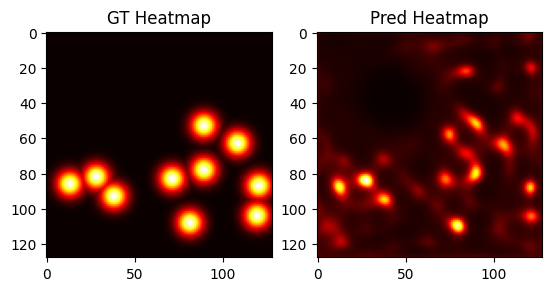


Epoch 36 completed in 168.15 seconds.
Train loss : 0.5154
Train mask loss : 0.3867
Train regr loss : 0.1287


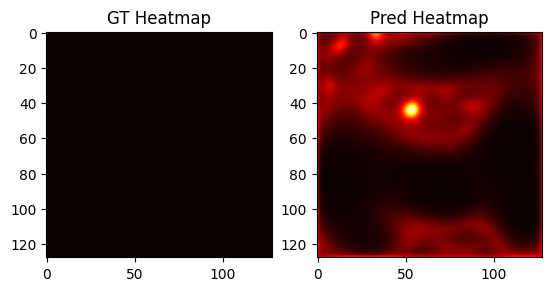


Validation loss      : 0.5670
Validation mask loss : 0.4963
Validation regr loss : 0.0707
Precision:        0.5381
Instance Recall:  0.5814
F1 Score:         0.5589
Normal Region FP: 0.0304093567251462
FROC Score:       0.6100
Current Learning Rate: 5.000000000000001e-07
No improvement in F1 Score for 2 epoch(s)

Epoch 37/100

Epoch 37 completed in 169.13 seconds.
Train loss : 0.5177
Train mask loss : 0.3894
Train regr loss : 0.1284

Validation loss      : 0.5623
Validation mask loss : 0.4921
Validation regr loss : 0.0702
Precision:        0.5440
Instance Recall:  0.5989
F1 Score:         0.5701
Normal Region FP: 0.03274853801169591
FROC Score:       0.6255
Current Learning Rate: 1e-07
F1 Score improved from 0.5681 to 0.5701

Epoch 38/100

Epoch 38 completed in 172.22 seconds.
Train loss : 0.5188
Train mask loss : 0.3906
Train regr loss : 0.1282

Validation loss      : 0.5896
Validation mask loss : 0.5193
Validation regr loss : 0.0703
Precision:        0.5582
Instance Recall:  0.5949


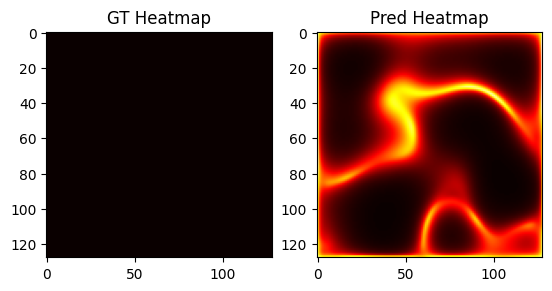


Epoch 41 completed in 168.47 seconds.
Train loss : 0.5290
Train mask loss : 0.4001
Train regr loss : 0.1289


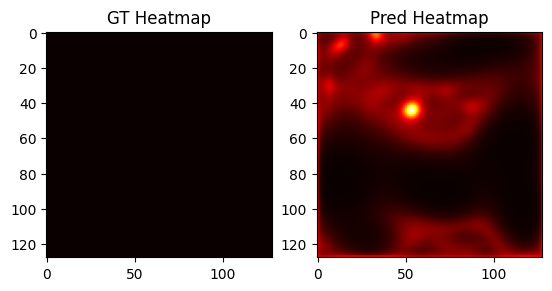


Validation loss      : 0.6054
Validation mask loss : 0.5349
Validation regr loss : 0.0705
Precision:        0.5146
Instance Recall:  0.5947
F1 Score:         0.5518
Normal Region FP: 0.03625730994152047
FROC Score:       0.6153
Current Learning Rate: 1e-07
No improvement in F1 Score for 3 epoch(s)

Epoch 42/100

Epoch 42 completed in 167.95 seconds.
Train loss : 0.5146
Train mask loss : 0.3878
Train regr loss : 0.1268

Validation loss      : 0.6063
Validation mask loss : 0.5354
Validation regr loss : 0.0708
Precision:        0.5384
Instance Recall:  0.5906
F1 Score:         0.5633
Normal Region FP: 0.03859649122807018
FROC Score:       0.6164
Current Learning Rate: 1e-07
No improvement in F1 Score for 4 epoch(s)

Epoch 43/100

Epoch 43 completed in 168.16 seconds.
Train loss : 0.5153
Train mask loss : 0.3849
Train regr loss : 0.1304

Validation loss      : 0.5781
Validation mask loss : 0.5073
Validation regr loss : 0.0709
Precision:        0.5276
Instance Recall:  0.5831
F1 Score:    

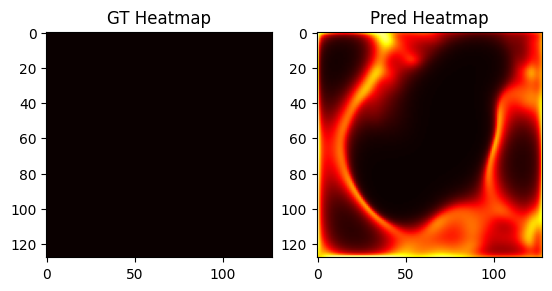


Epoch 46 completed in 168.69 seconds.
Train loss : 0.5000
Train mask loss : 0.3741
Train regr loss : 0.1259


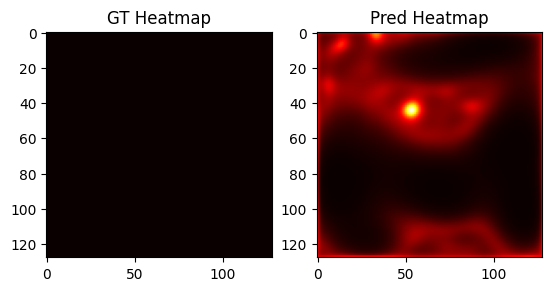


Validation loss      : 0.5575
Validation mask loss : 0.4866
Validation regr loss : 0.0708
Precision:        0.5323
Instance Recall:  0.5699
F1 Score:         0.5505
Normal Region FP: 0.022222222222222223
FROC Score:       0.5972
Current Learning Rate: 1e-07
No improvement in F1 Score for 8 epoch(s)

Epoch 47/100

Epoch 47 completed in 168.60 seconds.
Train loss : 0.5402
Train mask loss : 0.4118
Train regr loss : 0.1285

Validation loss      : 0.5400
Validation mask loss : 0.4693
Validation regr loss : 0.0707
Precision:        0.5483
Instance Recall:  0.5814
F1 Score:         0.5643
Normal Region FP: 0.021052631578947368
FROC Score:       0.6117
Current Learning Rate: 1e-07
No improvement in F1 Score for 9 epoch(s)

Epoch 48/100

Epoch 48 completed in 168.43 seconds.
Train loss : 0.5117
Train mask loss : 0.3831
Train regr loss : 0.1285

Validation loss      : 0.5529
Validation mask loss : 0.4821
Validation regr loss : 0.0708
Precision:        0.5334
Instance Recall:  0.5814
F1 Score:  

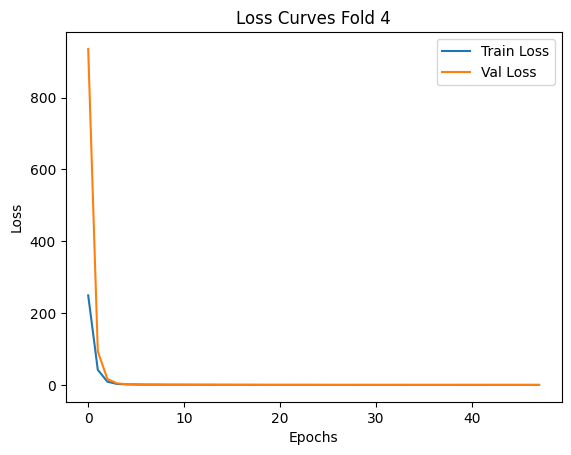


 Test Result
Precision: 0.5019
Instance Recall: 0.5101
F1 Score:  0.5060
FPs:       99.9645
FROC Score: 0.5505
Saved results to: /content/drive/MyDrive/Dissertation_Chatwipa/model_checkpoint/baseline_augmented/adamw18_checkpoints_20250710_164037/fold4/test_results.csv

=== Cross-validation results ===
Mean Best F1 Score: 0.5552 ± 0.0319


In [ ]:
# Get current timestamp (format: YYYYMMDD_HHMMSS)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Create save directory with timestamp
save_dir = f'/content/drive/MyDrive/Dissertation_Chatwipa/model_checkpoint/baseline_augmented/adamw18_checkpoints_{timestamp}'
os.makedirs(save_dir, exist_ok=True)

epochs = 100
early_stop_patience = 10
batch_size = 16
folds = ['fold1', 'fold2', 'fold3', 'fold4']
all_fold_metrics = []

for test_fold_idx, test_fold_name in enumerate(folds):
    val_fold_idx = (test_fold_idx + 1) % 4
    train_fold_idxs = [i for i in range(4) if i != test_fold_idx and i != val_fold_idx]

    print(f"==== Test Fold: {folds[test_fold_idx]}, Val Fold: {folds[val_fold_idx]}, Train Folds: {[folds[i] for i in train_fold_idxs]} ====")

    train_loader, val_loader, test_loader = get_dataloaders(
        fold_root_dir = "/content/drive/MyDrive/Dissertation_Chatwipa/dataset",
        train_fold = [folds[i] for i in train_fold_idxs],
        val_fold = folds[val_fold_idx],
        test_fold = folds[test_fold_idx],
        transform_train = train_transform,
        transform_val_test = val_test_transform,
        batch_size = batch_size
    )

    # Initialize/reset model, optimizer, scheduler
    model = centernet(model_name='resnet18')
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-5)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, min_lr=1e-7)

    best_f1 = float('-inf')
    epochs_no_improve = 0
    early_stop_flag = False

    # Create save directory per fold
    fold_save_dir = os.path.join(save_dir, f'{folds[test_fold_idx]}')
    os.makedirs(fold_save_dir, exist_ok=True)

    train_loss_all = []
    val_loss_all = []
    metrics_log = []

    for epoch in range(epochs):
        early_stop_flag, best_f1, epochs_no_improve, train_loss, val_loss, val_metrics = train(
            epoch, fold_save_dir, best_f1,
            epochs_no_improve, early_stop_patience,
            train_loader, val_loader,
            model, optimizer
        )

        train_loss_all.append(train_loss)
        val_loss_all.append(val_loss)

        metrics_log.append({
            'epoch': epoch+1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            **val_metrics
        })

        if early_stop_flag:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Save fold metrics to CSV
    metrics_df = pd.DataFrame(metrics_log)
    metrics_df.to_csv(os.path.join(fold_save_dir, 'training_metrics.csv'), index=False)

    # Plot loss curve
    plt.figure()
    plt.plot(train_loss_all, label='Train Loss')
    plt.plot(val_loss_all, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"Loss Curves Fold {test_fold_idx+1}")
    plt.show()

    # Save best f1 score
    all_fold_metrics.append({
        'fold': test_fold_idx + 1,
        'best_f1_score': best_f1
    })

    # ----- Test ------ #
    model_path = os.path.join(fold_save_dir, 'best_model.pth')
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    # checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("\n Test Result")
    metrics, froc, recall_list, csv_path = test(model, test_loader, device, fold_save_dir, plot = False)
    print(f"Saved results to: {csv_path}")

best_f1_scores = [fm['best_f1_score'] for fm in all_fold_metrics]

print("\n=== Cross-validation results ===")
print(f"Mean Best F1 Score: {np.mean(best_f1_scores):.4f} ± {np.std(best_f1_scores):.4f}")